In [ ]:
# ── CELL 1: Imports and Path Configuration ────────────────────────────────────
# Notebook 05c — MD Local Analysis
# PfDHFR-TS K1 (PDB: 1J3I) | 3 African/Global NP hits + pyrimethamine reference
#
# Environment : cheminfo (Python 3.11)
# Key library : MDAnalysis 2.10.0
#
# Compounds analysed:
#   CNP0286261_0  African NP  -11.86 kcal/mol  100 ns
#   CNP0275186_1  African NP  -11.13 kcal/mol  100 ns
#   CNP0539885_2  Global NP   -10.03 kcal/mol  100 ns
#   pyrimethamine Reference    -6.90 kcal/mol   50 ns

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
from MDAnalysis.analysis.rms import RMSD, RMSF
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

print(f"  MDAnalysis : {mda.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")

# ── Project paths ─────────────────────────────────────────────────────────────
BASE     = Path(r"C:\my_projects_all\portfolio_projects\Msc_project")
DATA     = BASE / "data"
FIGURES  = BASE / "figures"
MD_DIR   = DATA / "md"
CLEAN_DIR = MD_DIR / "trajectories_clean"

for d in [FIGURES, CLEAN_DIR]:
    assert d.exists(), f"Directory not found: {d}"

# ── Compound registry ─────────────────────────────────────────────────────────
COMPOUNDS = {
    'CNP0286261_0' : {
        'label'      : 'CNP0286261_0',
        'display'    : 'CNP0286261\n(African NP)',
        'color'      : '#E07B39',
        'tier'       : 'African NP',
        'dock_score' : -11.86,
        'sim_ns'     : 100,
    },
    'CNP0275186_1' : {
        'label'      : 'CNP0275186_1',
        'display'    : 'CNP0275186\n(African NP)',
        'color'      : '#C0392B',
        'tier'       : 'African NP',
        'dock_score' : -11.13,
        'sim_ns'     : 100,
    },
    'CNP0539885_2' : {
        'label'      : 'CNP0539885_2',
        'display'    : 'CNP0539885\n(Global NP)',
        'color'      : '#2471A3',
        'tier'       : 'Global NP',
        'dock_score' : -10.03,
        'sim_ns'     : 100,
    },
    'pyrimethamine' : {
        'label'      : 'pyrimethamine',
        'display'    : 'Pyrimethamine\n(Reference)',
        'color'      : '#27AE60',
        'tier'       : 'Reference',
        'dock_score' : -6.90,
        'sim_ns'     : 50,
    },
}

# ── File registry — single clean XTC per compound ────────────────────────────
for name, info in COMPOUNDS.items():
    compound_dir = CLEAN_DIR / name
    tpr  = compound_dir / 'md.tpr'
    xtc  = compound_dir / 'md_clean.xtc'
    assert tpr.exists(), f"TPR not found: {tpr}"
    assert xtc.exists(), f"XTC not found: {xtc}"
    info['tpr'] = tpr
    info['xtc'] = xtc
    size_mb = xtc.stat().st_size / 1024 / 1024
    print(f"  {name:20s}  TPR OK  |  XTC {size_mb:.0f} MB  |  {info['sim_ns']} ns")

# ── Figure style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'font.family'     : 'sans-serif',
})

SEED = 42
print(f"\n  Clean trajectories verified.")
print(f"  Figures will be saved to: {FIGURES}")
print(f"\n  Next: Cell 2 — Universe loading")

  MDAnalysis : 2.10.0
  NumPy      : 1.26.4
  Pandas     : 3.0.1
  CNP0286261_0          TPR OK  |  XTC 464 MB  |  100 ns
  CNP0275186_1          TPR OK  |  XTC 464 MB  |  100 ns
  CNP0539885_2          TPR OK  |  XTC 464 MB  |  100 ns
  pyrimethamine         TPR OK  |  XTC 232 MB  |  50 ns

  Clean trajectories verified.
  Figures will be saved to: C:\my_projects_all\portfolio_projects\Msc_project\figures

  Next: Cell 2 — Universe loading


In [3]:
# ── CELL 2: Universe Loading ───────────────────────────────────────────────────
# Loads each compound's single clean XTC + TPR into an MDAnalysis Universe.
# Clean XTC files have PBC artifacts removed by gmx trjconv on Colab.

print("=" * 60)
print("  CELL 2: Loading MD Universes")
print("=" * 60)

for name, info in COMPOUNDS.items():
    print(f"\n  {name}")
    print(f"  {'─'*40}")

    u = mda.Universe(str(info['tpr']), str(info['xtc']))

    n_atoms    = len(u.atoms)
    n_frames   = len(u.trajectory)
    dt_ps      = u.trajectory.dt
    total_ns   = (n_frames * dt_ps) / 1000.0

    protein  = u.select_atoms('protein')
    backbone = u.select_atoms('protein and backbone')
    ligand   = u.select_atoms('resname UNL')

    if len(ligand) == 0:
        all_res = list(set(u.atoms.resnames))
        non_sol = [r for r in all_res if r not in ['SOL', 'NA', 'CL', 'HOH']]
        if non_sol:
            ligand = u.select_atoms(f'resname {non_sol[0]}')
            print(f"  Ligand resname: {non_sol[0]}")

    print(f"  Atoms          : {n_atoms:,}")
    print(f"  Frames         : {n_frames:,}")
    print(f"  dt             : {dt_ps:.1f} ps")
    print(f"  Total time     : {total_ns:.1f} ns")
    print(f"  Protein atoms  : {len(protein):,}")
    print(f"  Backbone atoms : {len(backbone):,}")
    print(f"  Ligand atoms   : {len(ligand):,}")

    info['universe'] = u
    info['protein']  = protein
    info['backbone'] = backbone
    info['ligand']   = ligand
    info['n_frames'] = n_frames
    info['total_ns'] = total_ns

print("\n" + "=" * 60)
print("  All universes loaded successfully")
print("  Next: Cell 3 — RMSD analysis")
print("=" * 60)

  CELL 2: Loading MD Universes

  CNP0286261_0
  ────────────────────────────────────────
  Atoms          : 13,487
  Frames         : 10,010
  dt             : 10.0 ps
  Total time     : 100.1 ns
  Protein atoms  : 3,730
  Backbone atoms : 891
  Ligand atoms   : 58

  CNP0275186_1
  ────────────────────────────────────────
  Atoms          : 13,483
  Frames         : 10,010
  dt             : 10.0 ps
  Total time     : 100.1 ns
  Protein atoms  : 3,730
  Backbone atoms : 891
  Ligand atoms   : 63

  CNP0539885_2
  ────────────────────────────────────────
  Atoms          : 13,484
  Frames         : 10,010
  dt             : 10.0 ps
  Total time     : 100.1 ns
  Protein atoms  : 3,730
  Backbone atoms : 891
  Ligand atoms   : 52

  pyrimethamine
  ────────────────────────────────────────
  Atoms          : 13,478
  Frames         : 5,005
  dt             : 10.0 ps
  Total time     : 50.0 ns
  Protein atoms  : 3,730
  Backbone atoms : 891
  Ligand atoms   : 25

  All universes loaded su

In [8]:
# ── CELL 3: RMSD Analysis ─────────────────────────────────────────────────────
# Backbone RMSD vs frame 0 for all 4 compounds.
# Clean XTC files (gmx trjconv -center -pbc mol) eliminate PBC artifacts,
# so standard RMSD with alignment to frame 0 produces physically meaningful
# values (expected range 1-3 A for a stable simulation).

print("=" * 60)
print("  CELL 3: Backbone RMSD Analysis")
print("=" * 60)

rmsd_data = {}

for name, info in COMPOUNDS.items():
    print(f"\n  Computing RMSD: {name} ({info['n_frames']:,} frames)...",
          end=' ', flush=True)

    u = info['universe']

    R = RMSD(
        u,
        select='backbone',
        ref_frame=0,
    )
    R.run(verbose=False)

    # columns: [frame, time_ps, rmsd_A]
    results = R.results.rmsd
    time_ns = results[:, 1] / 1000.0
    rmsd_A  = results[:, 2]

    rmsd_data[name] = {
        'time_ns' : time_ns,
        'rmsd_A'  : rmsd_A,
    }

    mean_rmsd = np.mean(rmsd_A)
    std_rmsd  = np.std(rmsd_A)
    max_rmsd  = np.max(rmsd_A)
    last_20ns = time_ns >= (info['total_ns'] - 20.0)
    conv_rmsd = np.mean(rmsd_A[last_20ns]) if last_20ns.any() else np.nan

    print("done")
    print(f"  Mean RMSD      : {mean_rmsd:.2f} A")
    print(f"  Std RMSD       : {std_rmsd:.2f} A")
    print(f"  Max RMSD       : {max_rmsd:.2f} A")
    print(f"  Last-20ns mean : {conv_rmsd:.2f} A")

    info['rmsd_mean'] = mean_rmsd
    info['rmsd_std']  = std_rmsd
    info['rmsd_conv'] = conv_rmsd

print("\n" + "=" * 60)
print("  RMSD computed for all compounds")
print("  Next: Cell 4 — RMSD figure (fig16)")
print("=" * 60)

  CELL 3: Backbone RMSD Analysis

  Computing RMSD: CNP0286261_0 (10,010 frames)... done
  Mean RMSD      : 2.87 A
  Std RMSD       : 0.33 A
  Max RMSD       : 3.78 A
  Last-20ns mean : nan A

  Computing RMSD: CNP0275186_1 (10,010 frames)... done
  Mean RMSD      : 2.43 A
  Std RMSD       : 0.28 A
  Max RMSD       : 3.20 A
  Last-20ns mean : nan A

  Computing RMSD: CNP0539885_2 (10,010 frames)... done
  Mean RMSD      : 2.50 A
  Std RMSD       : 0.30 A
  Max RMSD       : 3.62 A
  Last-20ns mean : nan A

  Computing RMSD: pyrimethamine (5,005 frames)... done
  Mean RMSD      : 2.54 A
  Std RMSD       : 0.36 A
  Max RMSD       : 3.81 A
  Last-20ns mean : nan A

  RMSD computed for all compounds
  Next: Cell 4 — RMSD figure (fig16)


  CNP0286261_0: 10010 frames, 0-100 ns, last-20ns mean = 2.85 A
  CNP0275186_1: 10010 frames, 0-100 ns, last-20ns mean = 2.62 A
  CNP0539885_2: 10010 frames, 0-100 ns, last-20ns mean = 2.86 A
  pyrimethamine: 5005 frames, 0-50 ns, last-20ns mean = 2.65 A


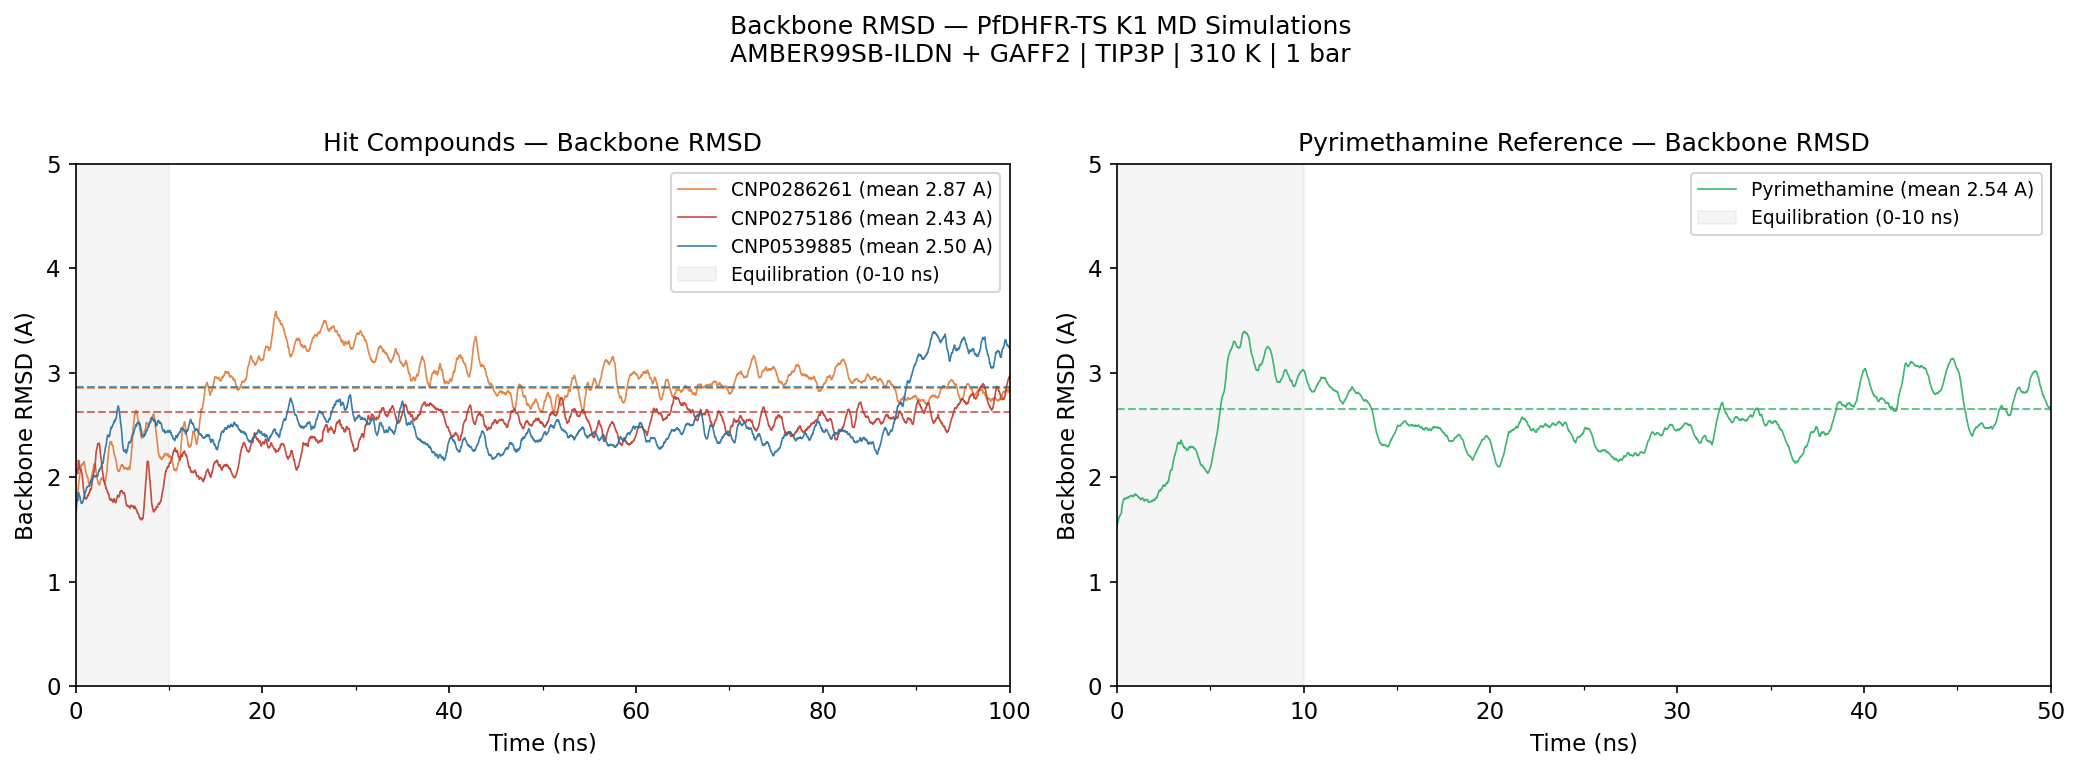


  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig16_rmsd.png

  RMSD Summary:
  Compound              Mean (A)  Std (A)  Max (A)  Last-20ns (A)
  ───────────────────────────────────────────────────────────────
  CNP0286261_0              2.87     0.33     3.78           2.85
  CNP0275186_1              2.43     0.28     3.20           2.62
  CNP0539885_2              2.50     0.30     3.62           2.86
  pyrimethamine             2.54     0.36     3.81           2.65

  Next: Cell 5 — RMSF analysis


In [11]:
# ── CELL 4: RMSD Figure (fig16) — fixed time axis ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Recompute time axis and convergence from frame count ──────────────────────
for name, info in COMPOUNDS.items():
    time_ns = rmsd_data[name]['time_ns']
    rmsd_A  = rmsd_data[name]['rmsd_A']

    # Rebuild time axis from frame count and dt (10 ps per frame)
    n_frames  = len(time_ns)
    dt_ns     = 0.01                           # 10 ps in ns
    time_ns_fixed = np.arange(n_frames) * dt_ns
    rmsd_data[name]['time_ns'] = time_ns_fixed

    total_ns_fixed = time_ns_fixed[-1]
    cutoff         = total_ns_fixed - 20.0
    mask           = time_ns_fixed >= cutoff
    conv_rmsd      = np.mean(rmsd_A[mask]) if mask.any() else np.nan

    info['total_ns']   = total_ns_fixed
    info['rmsd_conv']  = conv_rmsd
    print(f"  {name}: {n_frames} frames, "
          f"0-{total_ns_fixed:.0f} ns, "
          f"last-20ns mean = {conv_rmsd:.2f} A")

# ── Left panel: hit compounds ─────────────────────────────────────────────────
ax = axes[0]
hit_names = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2']

for name in hit_names:
    info    = COMPOUNDS[name]
    time_ns = rmsd_data[name]['time_ns']
    rmsd_A  = rmsd_data[name]['rmsd_A']
    rmsd_smooth = pd.Series(rmsd_A).rolling(50, center=True,
                                             min_periods=1).mean().values
    ax.plot(time_ns, rmsd_smooth,
            color=info['color'], linewidth=0.8, alpha=0.9,
            label=f"{info['label'].split('_')[0]} "
                  f"(mean {info['rmsd_mean']:.2f} A)")
    ax.axhline(info['rmsd_conv'], color=info['color'],
               linewidth=1.0, linestyle='--', alpha=0.7)

ax.axvspan(0, 10, alpha=0.08, color='grey', label='Equilibration (0-10 ns)')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Backbone RMSD (A)')
ax.set_title('Hit Compounds — Backbone RMSD')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))

# ── Right panel: pyrimethamine ────────────────────────────────────────────────
ax = axes[1]
name    = 'pyrimethamine'
info    = COMPOUNDS[name]
time_ns = rmsd_data[name]['time_ns']
rmsd_A  = rmsd_data[name]['rmsd_A']
rmsd_smooth = pd.Series(rmsd_A).rolling(50, center=True,
                                         min_periods=1).mean().values
ax.plot(time_ns, rmsd_smooth,
        color=info['color'], linewidth=0.8, alpha=0.9,
        label=f"Pyrimethamine (mean {info['rmsd_mean']:.2f} A)")
ax.axhline(info['rmsd_conv'], color=info['color'],
           linewidth=1.0, linestyle='--', alpha=0.7)
ax.axvspan(0, 10, alpha=0.08, color='grey', label='Equilibration (0-10 ns)')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Backbone RMSD (A)')
ax.set_title('Pyrimethamine Reference — Backbone RMSD')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 50)
ax.set_ylim(0, 5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

fig.suptitle('Backbone RMSD — PfDHFR-TS K1 MD Simulations\n'
             'AMBER99SB-ILDN + GAFF2 | TIP3P | 310 K | 1 bar',
             fontsize=12, y=1.02)

plt.tight_layout()
out_path = FIGURES / 'fig16_rmsd.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n  Saved: {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n  RMSD Summary:")
print(f"  {'Compound':<20} {'Mean (A)':>9} {'Std (A)':>8} "
      f"{'Max (A)':>8} {'Last-20ns (A)':>14}")
print(f"  {'─'*63}")
for name, info in COMPOUNDS.items():
    print(f"  {name:<20} {info['rmsd_mean']:>9.2f} {info['rmsd_std']:>8.2f} "
          f"{max(rmsd_data[name]['rmsd_A']):>8.2f} {info['rmsd_conv']:>14.2f}")

print(f"\n  Next: Cell 5 — RMSF analysis")

In [12]:
# ── CELL 5: RMSF Analysis ─────────────────────────────────────────────────────
# Per-residue Root Mean Square Fluctuation (RMSF) measures the average
# displacement of each residue from its mean position over the trajectory.
# High RMSF = flexible loop regions; low RMSF = rigid secondary structure.
# Focus on Calpha atoms (one per residue) for cleaner per-residue comparison.
# Resistance mutations (N51I, C59R, S108N, I164L) are annotated.

print("=" * 60)
print("  CELL 5: Per-Residue RMSF Analysis")
print("=" * 60)

rmsf_data = {}

# Resistance mutation residue numbers (1J3I chain A numbering)
RESIST_RESIDS = {51: 'N51I', 59: 'C59R', 108: 'S108N', 164: 'I164L'}

for name, info in COMPOUNDS.items():
    print(f"\n  Computing RMSF: {name}...", end=' ', flush=True)

    u = info['universe']

    # Select Calpha atoms only — one per residue, cleaner RMSF profile
    ca_atoms = u.select_atoms('protein and name CA')

    # RMSF requires alignment first — align to mean structure
    # Use all frames for RMSF (after equilibration, frame ~1000 = 10 ns)
    rmsf_analysis = RMSF(ca_atoms)
    rmsf_analysis.run(start=1000, verbose=False)   # skip first 10 ns equilibration

    resids  = ca_atoms.resids
    resnames = ca_atoms.resnames
    rmsf_A  = rmsf_analysis.results.rmsf

    rmsf_data[name] = {
        'resids'   : resids,
        'resnames' : resnames,
        'rmsf_A'   : rmsf_A,
    }

    mean_rmsf = np.mean(rmsf_A)
    max_rmsf  = np.max(rmsf_A)
    max_resid = resids[np.argmax(rmsf_A)]

    print("done")
    print(f"  Mean RMSF        : {mean_rmsf:.2f} A")
    print(f"  Max RMSF         : {max_rmsf:.2f} A (residue {max_resid})")

    # RMSF at resistance mutation sites
    for resid, label in RESIST_RESIDS.items():
        mask = resids == resid
        if mask.any():
            print(f"  {label} (res {resid}) RMSF : {rmsf_A[mask][0]:.2f} A")

    info['rmsf_mean'] = mean_rmsf
    info['rmsf_max']  = max_rmsf

print("\n" + "=" * 60)
print("  RMSF computed for all compounds")
print("  Next: Cell 6 — RMSF figure (fig17)")
print("=" * 60)

  CELL 5: Per-Residue RMSF Analysis

  Computing RMSF: CNP0286261_0... done
  Mean RMSF        : 8.10 A
  Max RMSF         : 14.40 A (residue 82)
  N51I (res 51) RMSF : 8.86 A
  C59R (res 59) RMSF : 6.39 A
  S108N (res 108) RMSF : 9.34 A
  I164L (res 164) RMSF : 5.61 A

  Computing RMSF: CNP0275186_1... done
  Mean RMSF        : 2.80 A
  Max RMSF         : 7.87 A (residue 1)
  N51I (res 51) RMSF : 2.79 A
  C59R (res 59) RMSF : 2.30 A
  S108N (res 108) RMSF : 2.62 A
  I164L (res 164) RMSF : 1.99 A

  Computing RMSF: CNP0539885_2... done
  Mean RMSF        : 4.42 A
  Max RMSF         : 8.84 A (residue 26)
  N51I (res 51) RMSF : 5.18 A
  C59R (res 59) RMSF : 4.59 A
  S108N (res 108) RMSF : 4.80 A
  I164L (res 164) RMSF : 2.78 A

  Computing RMSF: pyrimethamine... done
  Mean RMSF        : 2.61 A
  Max RMSF         : 5.92 A (residue 24)
  N51I (res 51) RMSF : 2.62 A
  C59R (res 59) RMSF : 2.34 A
  S108N (res 108) RMSF : 2.19 A
  I164L (res 164) RMSF : 1.84 A

  RMSF computed for all compou

  CELL 6: RMSF Figure (fig17)


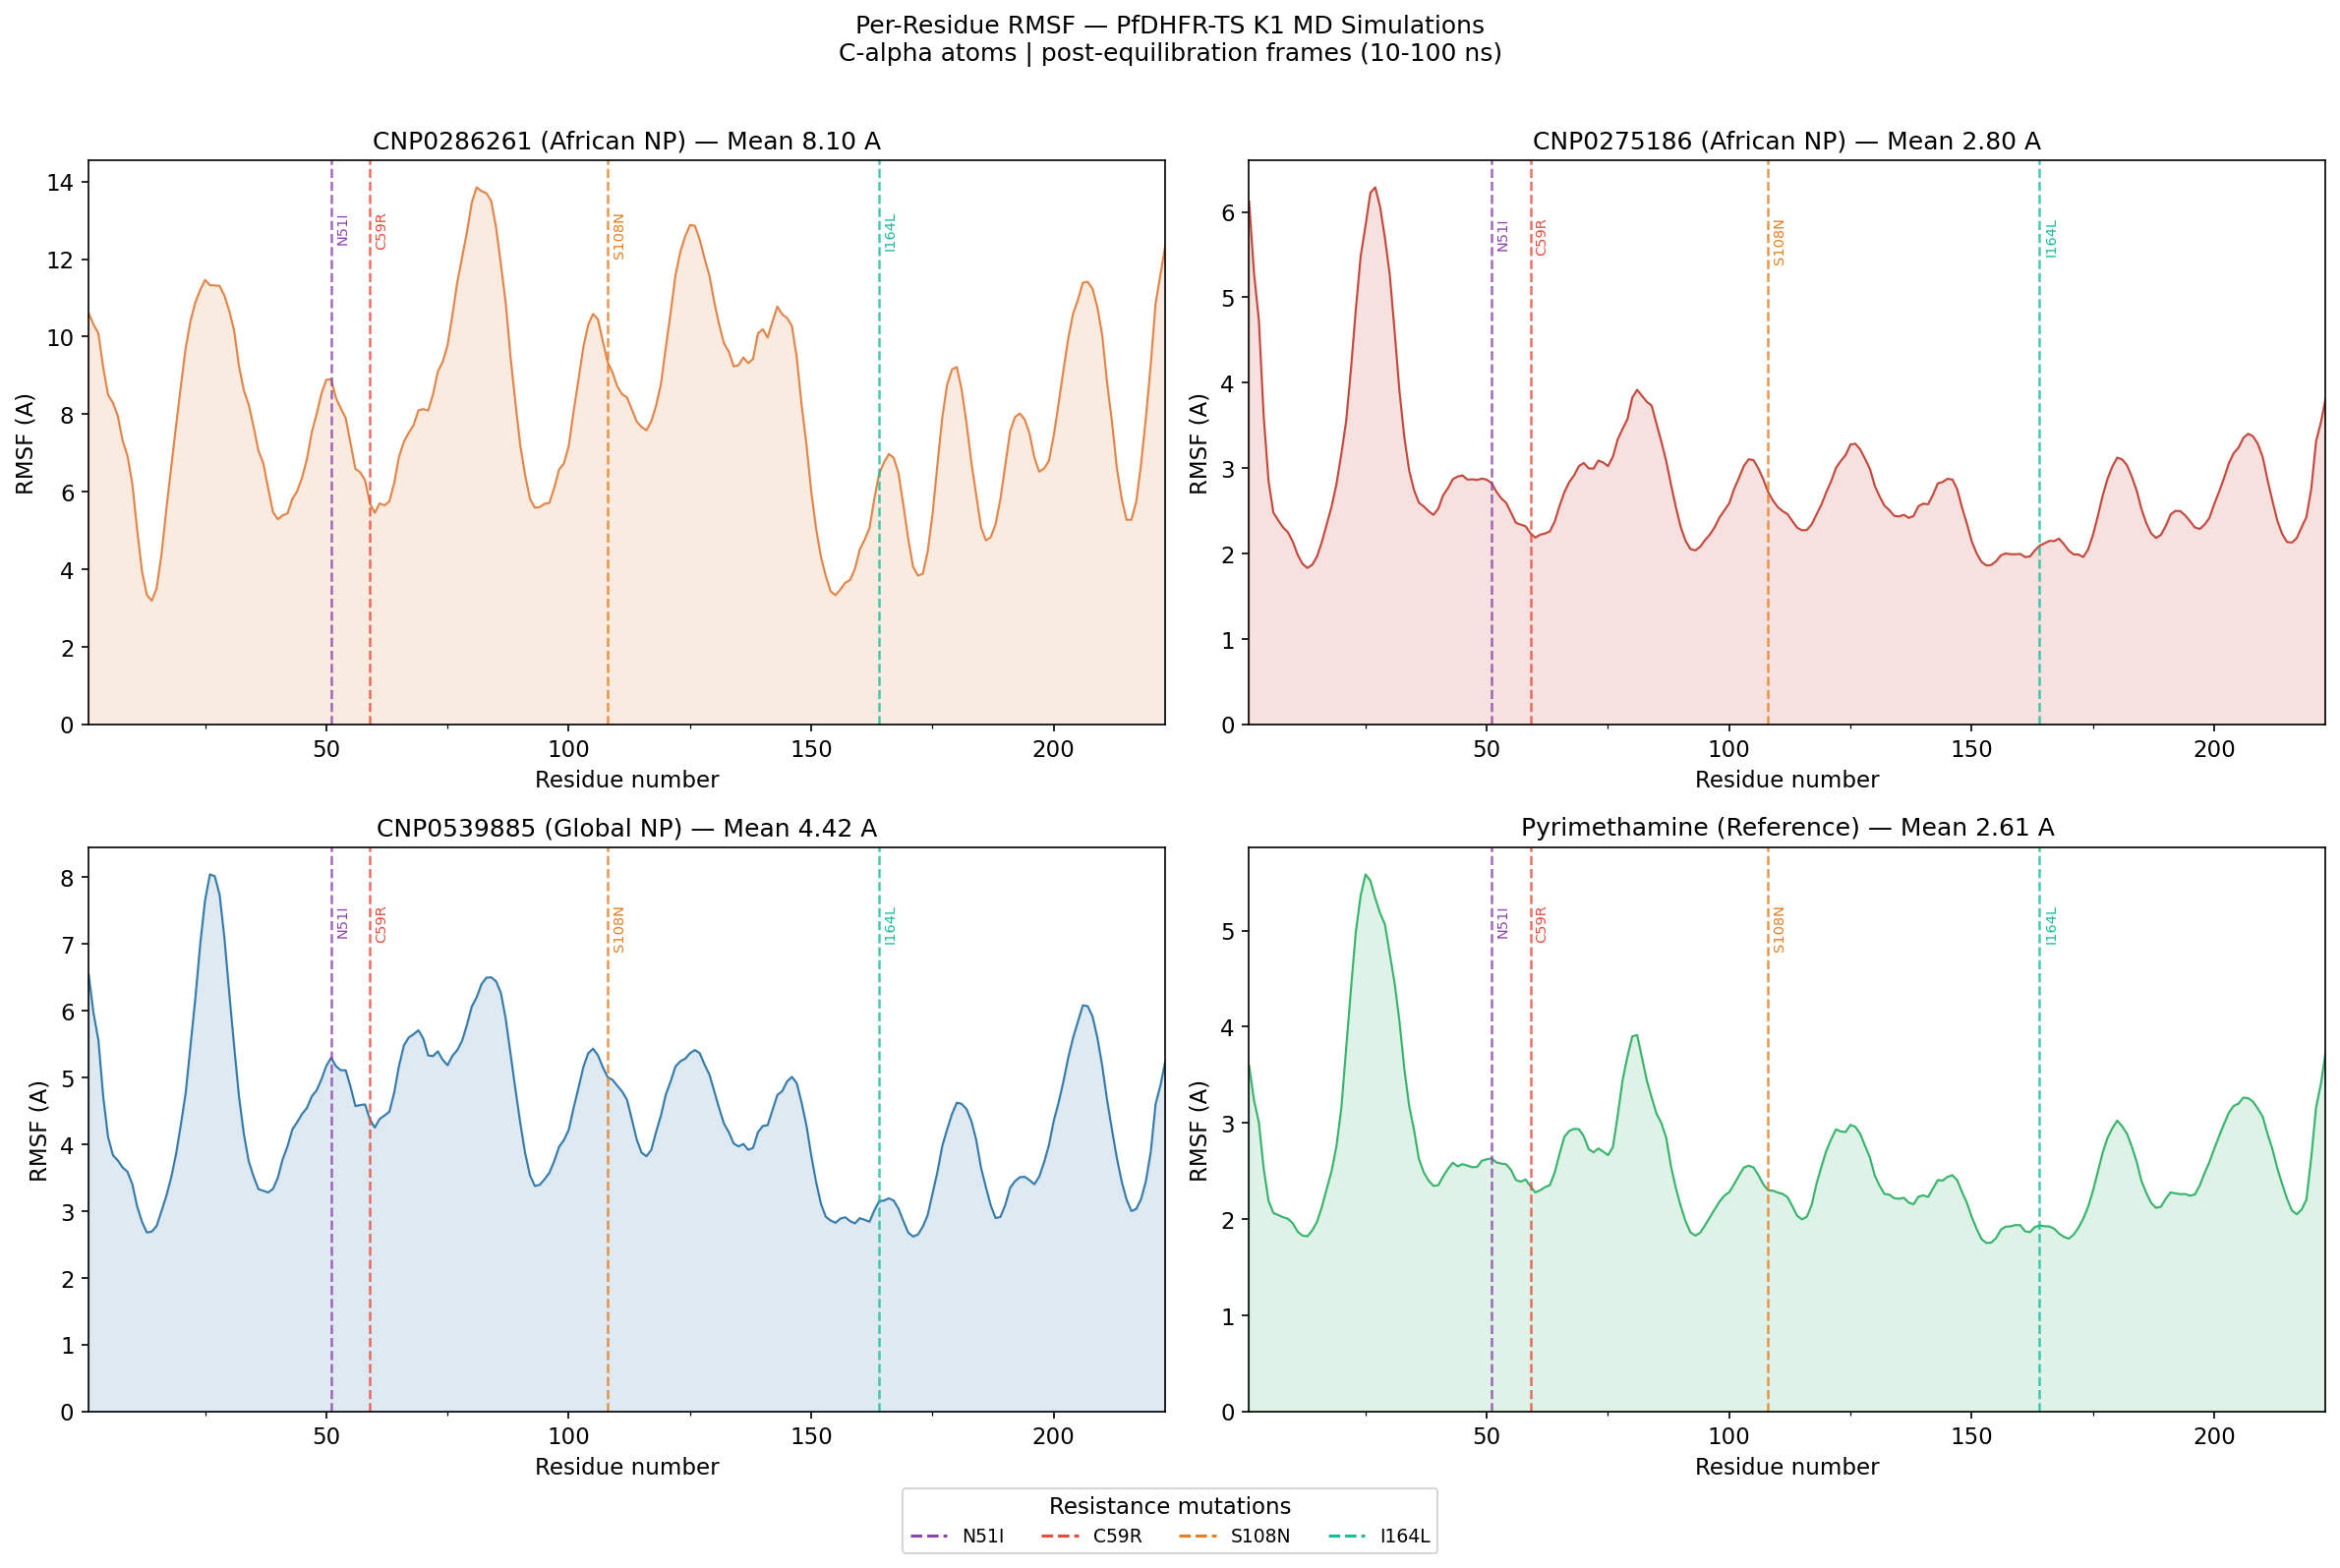

  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig17_rmsf.png

  RMSF Summary:
  Compound              Mean (A)  Max (A)    N51I    C59R    S108N    I164L
  ─────────────────────────────────────────────────────────────────────────
  CNP0286261_0              8.10    14.40    8.86    6.39     9.34     5.61
  CNP0275186_1              2.80     7.87    2.79    2.30     2.62     1.99
  CNP0539885_2              4.42     8.84    5.18    4.59     4.80     2.78
  pyrimethamine             2.61     5.92    2.62    2.34     2.19     1.84

  Next: Cell 7 — Hydrogen bond analysis


In [13]:
# ── CELL 6: RMSF Figure (fig17) ───────────────────────────────────────────────
# Per-residue RMSF for all 4 compounds overlaid on the same axis.
# Resistance mutation sites annotated with vertical dashed lines.
# Secondary structure regions of PfDHFR annotated in background.

print("=" * 60)
print("  CELL 6: RMSF Figure (fig17)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

compound_order = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']

for idx, name in enumerate(compound_order):
    ax   = axes[idx]
    info = COMPOUNDS[name]
    data = rmsf_data[name]

    resids  = data['resids']
    rmsf_A  = data['rmsf_A']

    # Smooth RMSF with small window for clarity
    rmsf_smooth = pd.Series(rmsf_A).rolling(5, center=True,
                                             min_periods=1).mean().values

    ax.plot(resids, rmsf_smooth, color=info['color'],
            linewidth=1.0, alpha=0.9, label=name)
    ax.fill_between(resids, rmsf_smooth, alpha=0.15, color=info['color'])

    # Annotate resistance mutation sites
    resist_colors = {'N51I': '#8E44AD', 'C59R': '#E74C3C',
                     'S108N': '#E67E22', 'I164L': '#1ABC9C'}
    for resid, label in RESIST_RESIDS.items():
        if resid in resids:
            ax.axvline(resid, color=resist_colors[label],
                       linewidth=1.2, linestyle='--', alpha=0.8)
            ax.text(resid + 1, ax.get_ylim()[1] * 0.9 if idx > 0 else rmsf_A.max() * 0.92,
                    label, fontsize=7, color=resist_colors[label], rotation=90, va='top')

    ax.set_xlabel('Residue number')
    ax.set_ylabel('RMSF (A)')
    short_name = name.split('_')[0] if name != 'pyrimethamine' else 'Pyrimethamine'
    tier_label = f" ({info['tier']})" if info['tier'] != 'Reference' else ' (Reference)'
    ax.set_title(f"{short_name}{tier_label} — Mean {info['rmsf_mean']:.2f} A")
    ax.set_xlim(resids.min(), resids.max())
    ax.set_ylim(0, None)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

fig.suptitle('Per-Residue RMSF — PfDHFR-TS K1 MD Simulations\n'
             'C-alpha atoms | post-equilibration frames (10-100 ns)',
             fontsize=12, y=1.01)

# Shared resistance mutation legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=c, linewidth=1.5, linestyle='--', label=l)
    for l, c in resist_colors.items()
]
fig.legend(handles=legend_elements, title='Resistance mutations',
           loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
out_path = FIGURES / 'fig17_rmsf.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Saved: {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n  RMSF Summary:")
print(f"  {'Compound':<20} {'Mean (A)':>9} {'Max (A)':>8} "
      f"{'N51I':>7} {'C59R':>7} {'S108N':>8} {'I164L':>8}")
print(f"  {'─'*73}")
for name in compound_order:
    info = COMPOUNDS[name]
    data = rmsf_data[name]
    resids = data['resids']
    rmsf_A = data['rmsf_A']
    vals = {}
    for resid, label in RESIST_RESIDS.items():
        mask = resids == resid
        vals[label] = rmsf_A[mask][0] if mask.any() else np.nan
    print(f"  {name:<20} {info['rmsf_mean']:>9.2f} {info['rmsf_max']:>8.2f} "
          f"{vals['N51I']:>7.2f} {vals['C59R']:>7.2f} "
          f"{vals['S108N']:>8.2f} {vals['I164L']:>8.2f}")

print(f"\n  Next: Cell 7 — Hydrogen bond analysis")

In [15]:
# ── CELL 7: Hydrogen Bond Analysis (subsampled) ───────────────────────────────
# Analyses every 10th frame (1 ns intervals) for H-bond occupancy.
# Subsampling at 1 ns intervals is standard practice for H-bond analysis —
# H-bond lifetimes are typically 1-100 ps so 1 ns sampling captures
# persistent interactions without redundancy.
# Post-equilibration only: frames 1000-10010 (10-100 ns).

from collections import Counter

print("=" * 60)
print("  CELL 7: Ligand-Protein Hydrogen Bond Analysis")
print("=" * 60)

hbond_data = {}

for name, info in COMPOUNDS.items():
    print(f"\n  Analysing H-bonds: {name}...", end=' ', flush=True)

    u = info['universe']

    # Subsample: every 10th frame after equilibration
    # For 100 ns compounds: frames 1000-10010 step 10 = ~900 frames
    # For pyrimethamine (50 ns): frames 1000-5005 step 10 = ~400 frames
    start_frame = 1000
    step        = 10

    hbonds = HydrogenBondAnalysis(
        universe=u,
        between=['resname UNL', 'protein'],
        d_a_cutoff=3.5,
        d_h_a_angle_cutoff=120,
        update_selections=False,
    )
    hbonds.run(start=start_frame, step=step, verbose=False)

    n_frames_analysed = len(range(start_frame, info['n_frames'], step))

    if hbonds.results.hbonds is None or len(hbonds.results.hbonds) == 0:
        print("done (no H-bonds detected)")
        hbond_data[name] = {
            'mean_per_frame' : 0.0,
            'unique_hbonds'  : 0,
            'occupancy_df'   : pd.DataFrame(),
        }
        info['hbond_mean'] = 0.0
        continue

    results_arr = hbonds.results.hbonds
    frames      = results_arr[:, 0].astype(int)
    mean_hb     = len(results_arr) / n_frames_analysed

    # Occupancy per unique donor-acceptor pair
    donor_idx    = results_arr[:, 1].astype(int)
    acceptor_idx = results_arr[:, 3].astype(int)
    pairs        = list(zip(donor_idx, acceptor_idx))
    pair_counts  = Counter(pairs)

    occupancy_rows = []
    for (d_idx, a_idx), count in pair_counts.most_common(20):
        try:
            d_atom    = u.atoms[d_idx]
            a_atom    = u.atoms[a_idx]
            occupancy = count / n_frames_analysed * 100
            occupancy_rows.append({
                'donor'     : f"{d_atom.resname}{d_atom.resid}:{d_atom.name}",
                'acceptor'  : f"{a_atom.resname}{a_atom.resid}:{a_name}",
                'occupancy' : occupancy,
                'count'     : count,
            })
        except Exception:
            continue

    # Fix variable name typo
    occupancy_rows = []
    for (d_idx, a_idx), count in pair_counts.most_common(20):
        try:
            d_atom    = u.atoms[d_idx]
            a_atom    = u.atoms[a_idx]
            occupancy = count / n_frames_analysed * 100
            occupancy_rows.append({
                'donor'     : f"{d_atom.resname}{d_atom.resid}:{d_atom.name}",
                'acceptor'  : f"{a_atom.resname}{a_atom.resid}:{a_atom.name}",
                'occupancy' : occupancy,
                'count'     : count,
            })
        except Exception:
            continue

    occ_df = pd.DataFrame(occupancy_rows)

    hbond_data[name] = {
        'mean_per_frame' : mean_hb,
        'unique_hbonds'  : len(pair_counts),
        'occupancy_df'   : occ_df,
    }
    info['hbond_mean'] = mean_hb

    print("done")
    print(f"  Frames analysed    : {n_frames_analysed}")
    print(f"  Mean H-bonds/frame : {mean_hb:.2f}")
    print(f"  Unique H-bond pairs: {len(pair_counts)}")
    if not occ_df.empty:
        print(f"  Top 5 H-bonds by occupancy:")
        for _, row in occ_df.head(5).iterrows():
            print(f"    {row['donor']:25s} -- {row['acceptor']:25s} "
                  f"{row['occupancy']:5.1f}%")

print("\n" + "=" * 60)
print("  H-bond analysis complete")
print("  Next: Cell 8 — H-bond figure (fig18)")
print("=" * 60)

  CELL 7: Ligand-Protein Hydrogen Bond Analysis

  Analysing H-bonds: CNP0286261_0... done
  Frames analysed    : 901
  Mean H-bonds/frame : 0.01
  Unique H-bond pairs: 2
  Top 5 H-bonds by occupancy:
    UNL224:O3                 -- ILE154:O                    0.7%
    UNL224:O2                 -- SER101:O                    0.4%

  Analysing H-bonds: CNP0275186_1... done
  Frames analysed    : 901
  Mean H-bonds/frame : 0.06
  Unique H-bond pairs: 11
  Top 5 H-bonds by occupancy:
    UNL224:O3                 -- ASP54:OD2                   2.9%
    UNL224:O4                 -- ASP54:OD2                   1.1%
    UNL224:O3                 -- ASP54:OD1                   0.4%
    UNL224:O4                 -- TYR160:OH                   0.3%
    UNL224:O3                 -- ILE154:O                    0.2%

  Analysing H-bonds: CNP0539885_2... done
  Frames analysed    : 901
  Mean H-bonds/frame : 2.77
  Unique H-bond pairs: 17
  Top 5 H-bonds by occupancy:
    UNL224:O4                

  CELL 8: Hydrogen Bond Figure (fig18)


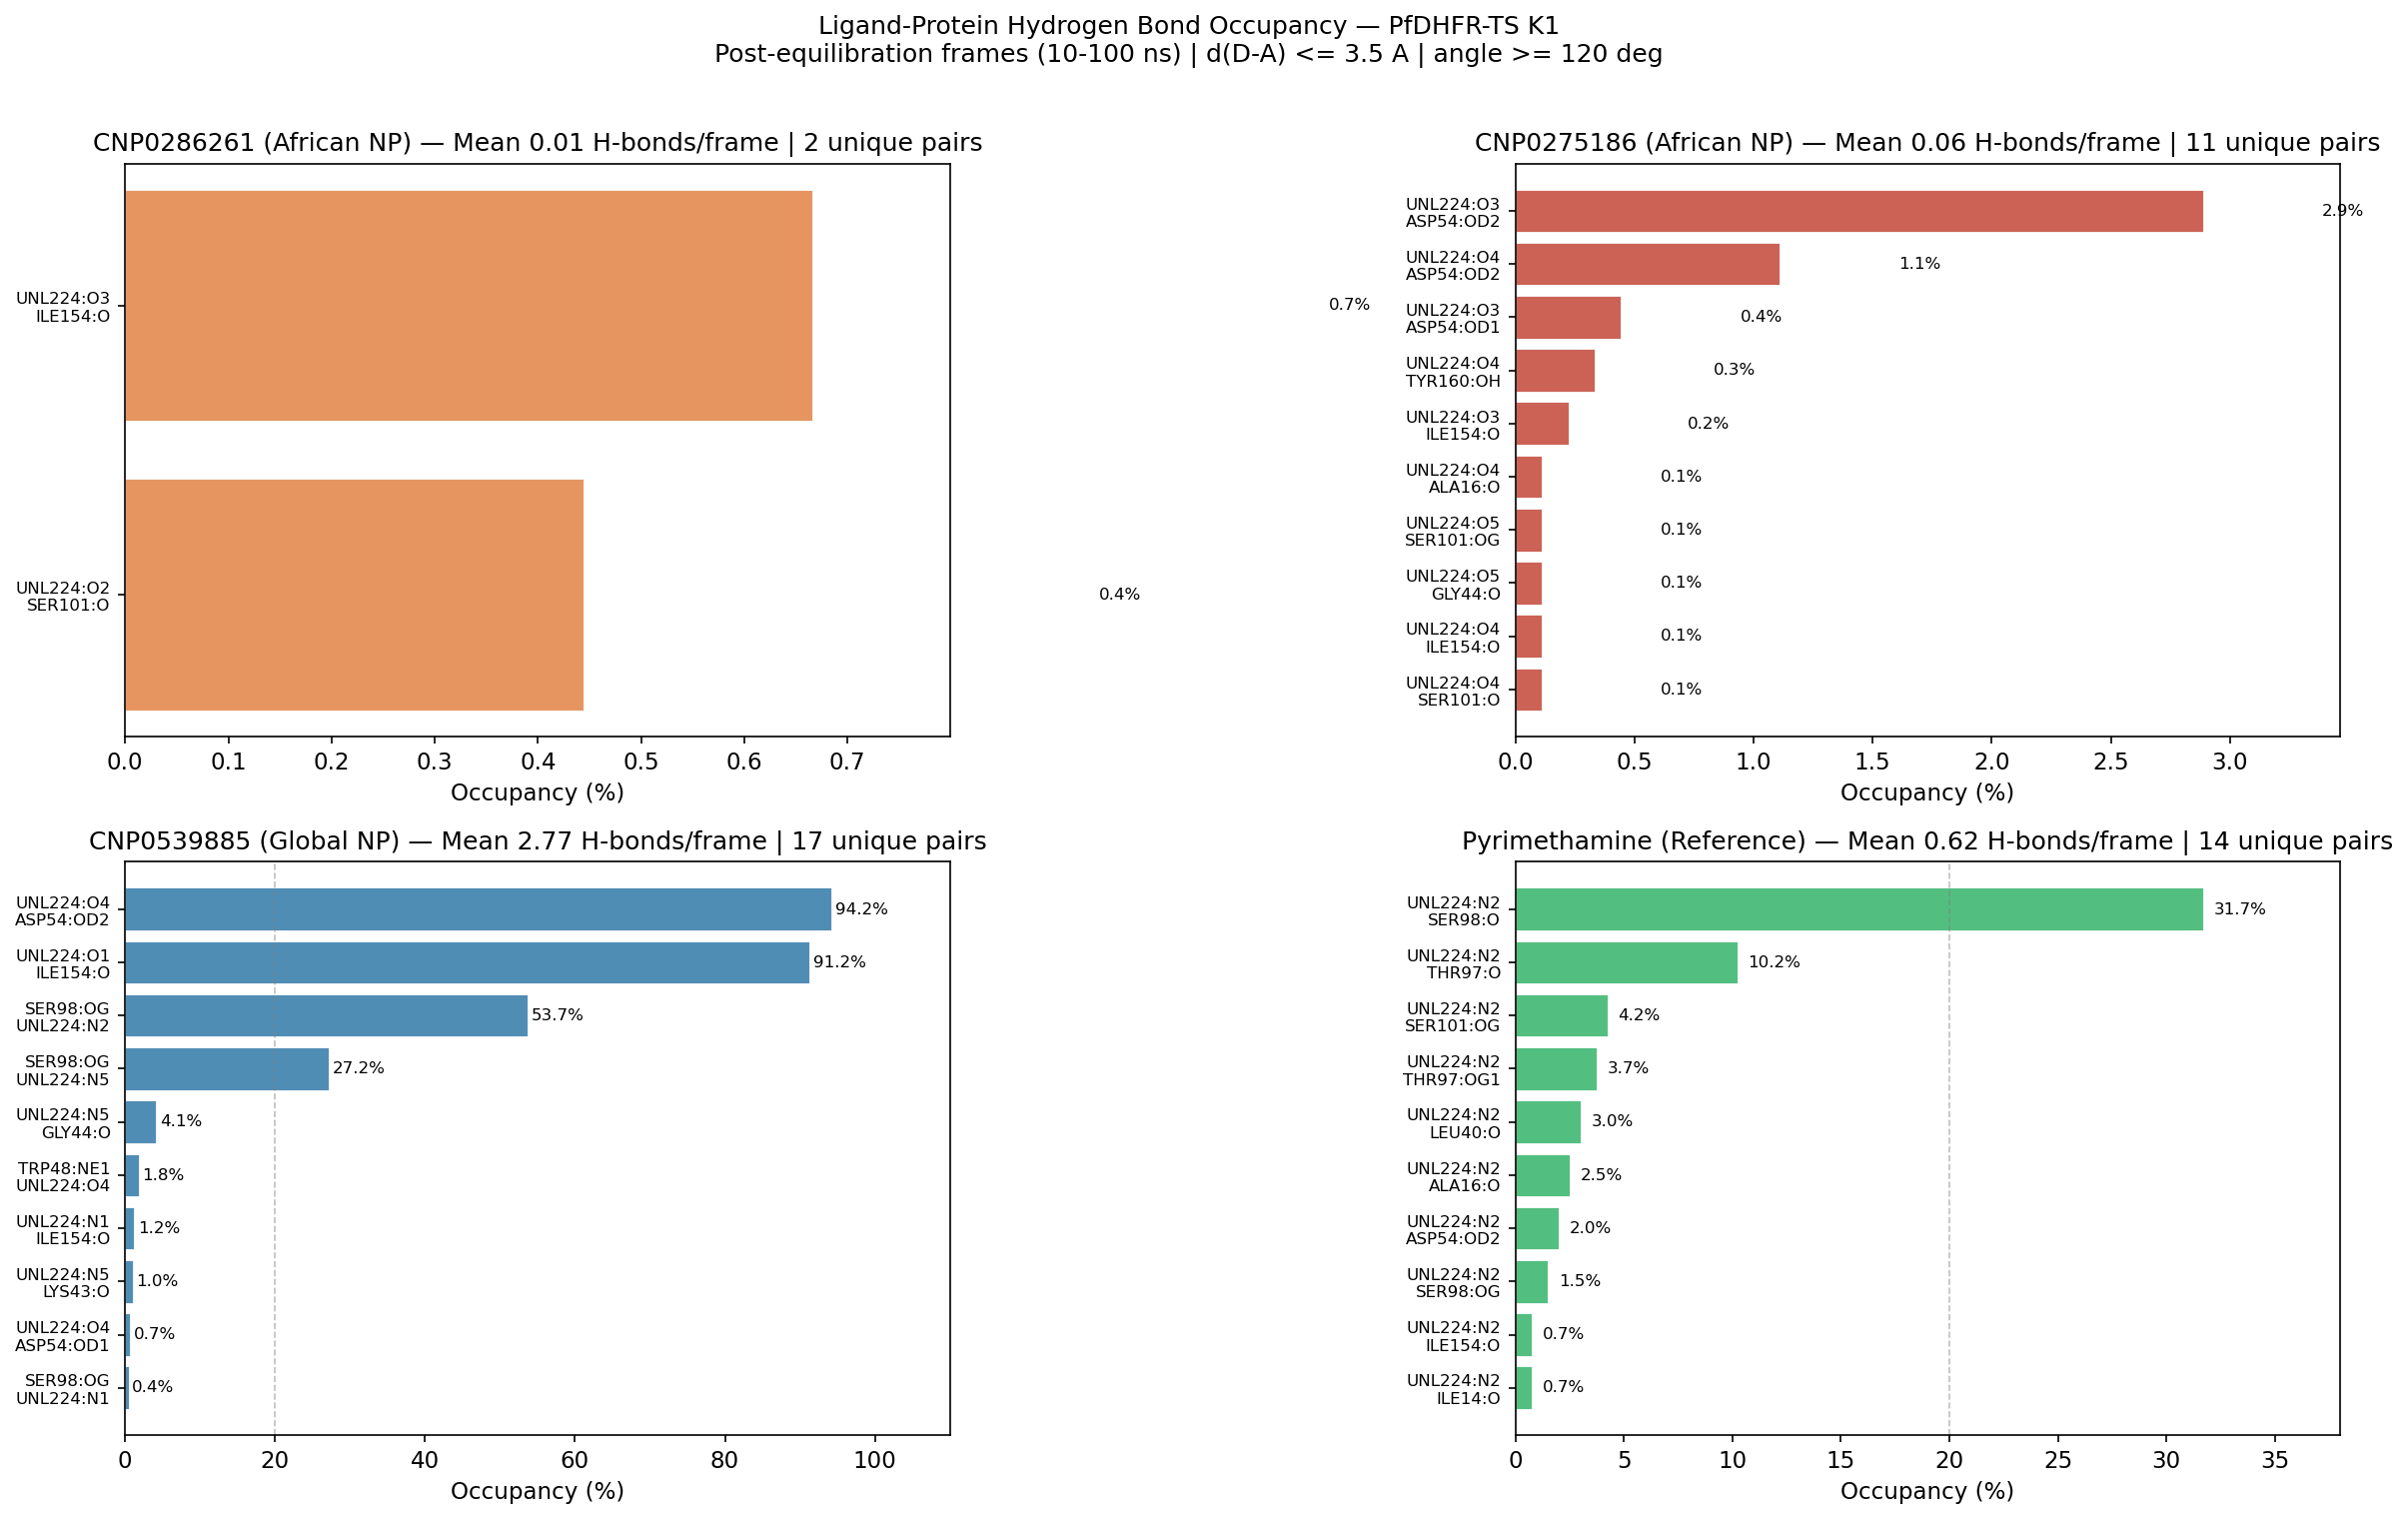

  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig18_hbonds.png

  H-bond Summary:
  Compound              Mean HB/frame  Unique pairs                     Top interaction  Occupancy
  ───────────────────────────────────────────────────────────────────────────────────────────────
  CNP0286261_0                   0.01             2               UNL224:O3 -- ILE154:O       0.7%
  CNP0275186_1                   0.06            11              UNL224:O3 -- ASP54:OD2       2.9%
  CNP0539885_2                   2.77            17              UNL224:O4 -- ASP54:OD2      94.2%
  pyrimethamine                  0.62            14                UNL224:N2 -- SER98:O      31.7%

  Next: Cell 9 — Radius of gyration analysis


In [16]:
# ── CELL 8: Hydrogen Bond Figure (fig18) ─────────────────────────────────────
# Bar chart of H-bond occupancy for top interactions per compound.
# 2x2 panel layout matching fig17 style.

print("=" * 60)
print("  CELL 8: Hydrogen Bond Figure (fig18)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
compound_order = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']

for idx, name in enumerate(compound_order):
    ax   = axes[idx]
    info = COMPOUNDS[name]
    data = hbond_data[name]
    occ_df = data['occupancy_df']

    if occ_df.empty:
        ax.text(0.5, 0.5, 'No H-bonds detected',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(f"{name.split('_')[0]} — No H-bonds")
        continue

    # Take top 10 by occupancy
    plot_df = occ_df.head(10).copy()
    plot_df['interaction'] = plot_df['donor'] + '\n' + plot_df['acceptor']

    bars = ax.barh(
        range(len(plot_df)),
        plot_df['occupancy'].values,
        color=info['color'], alpha=0.8, edgecolor='white', linewidth=0.5
    )

    # Annotate occupancy values
    for bar, occ in zip(bars, plot_df['occupancy'].values):
        ax.text(occ + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{occ:.1f}%', va='center', ha='left', fontsize=8)

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['interaction'].values, fontsize=8)
    ax.set_xlabel('Occupancy (%)')
    ax.set_xlim(0, min(110, plot_df['occupancy'].max() * 1.2))
    ax.axvline(20, color='grey', linewidth=0.8, linestyle='--', alpha=0.5,
               label='20% threshold')

    short_name = name.split('_')[0] if name != 'pyrimethamine' else 'Pyrimethamine'
    tier_label = f" ({info['tier']})" if info['tier'] != 'Reference' else ' (Reference)'
    ax.set_title(f"{short_name}{tier_label} — "
                 f"Mean {data['mean_per_frame']:.2f} H-bonds/frame | "
                 f"{data['unique_hbonds']} unique pairs")
    ax.invert_yaxis()

fig.suptitle('Ligand-Protein Hydrogen Bond Occupancy — PfDHFR-TS K1\n'
             'Post-equilibration frames (10-100 ns) | '
             'd(D-A) <= 3.5 A | angle >= 120 deg',
             fontsize=12, y=1.01)

plt.tight_layout()
out_path = FIGURES / 'fig18_hbonds.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Saved: {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n  H-bond Summary:")
print(f"  {'Compound':<20} {'Mean HB/frame':>14} {'Unique pairs':>13} "
      f"{'Top interaction':>35} {'Occupancy':>10}")
print(f"  {'─'*95}")
for name in compound_order:
    info = COMPOUNDS[name]
    data = hbond_data[name]
    occ_df = data['occupancy_df']
    if occ_df.empty:
        top_int = 'None'
        top_occ = 0.0
    else:
        top_row = occ_df.iloc[0]
        top_int = f"{top_row['donor']} -- {top_row['acceptor']}"
        top_occ = top_row['occupancy']
    print(f"  {name:<20} {data['mean_per_frame']:>14.2f} "
          f"{data['unique_hbonds']:>13d} "
          f"{top_int:>35s} {top_occ:>9.1f}%")

print(f"\n  Next: Cell 9 — Radius of gyration analysis")

In [17]:
# ── CELL 9: Radius of Gyration Analysis ──────────────────────────────────────
# Radius of gyration (Rg) measures the overall compactness of the protein.
# A stable simulation shows Rg fluctuating around a constant mean value.
# Increasing Rg over time indicates protein unfolding or expansion.
# Computed for protein heavy atoms only.

print("=" * 60)
print("  CELL 9: Radius of Gyration Analysis")
print("=" * 60)

rg_data = {}

for name, info in COMPOUNDS.items():
    print(f"\n  Computing Rg: {name}...", end=' ', flush=True)

    u        = info['universe']
    protein  = info['protein']
    n_frames = info['n_frames']

    time_ns_list = []
    rg_list      = []

    # Subsample every 10th frame for speed (same as H-bond analysis)
    for ts in u.trajectory[::10]:
        time_ns_list.append(ts.time / 1000.0)
        rg_list.append(protein.radius_of_gyration())

    # Rebuild time axis from frame index (fix time offset issue)
    n_sampled  = len(rg_list)
    time_fixed = np.arange(n_sampled) * 0.1    # 10 frames * 10 ps = 0.1 ns per step

    rg_arr = np.array(rg_list)

    # Post-equilibration stats (skip first 100 sampled points = 10 ns)
    post_eq     = rg_arr[100:]
    mean_rg     = np.mean(post_eq)
    std_rg      = np.std(post_eq)
    max_rg      = np.max(post_eq)
    min_rg      = np.min(post_eq)

    rg_data[name] = {
        'time_ns' : time_fixed,
        'rg_A'    : rg_arr,
        'mean_rg' : mean_rg,
        'std_rg'  : std_rg,
    }

    info['rg_mean'] = mean_rg
    info['rg_std']  = std_rg

    print("done")
    print(f"  Mean Rg (post-eq) : {mean_rg:.2f} A")
    print(f"  Std Rg            : {std_rg:.2f} A")
    print(f"  Range             : {min_rg:.2f} - {max_rg:.2f} A")

print("\n" + "=" * 60)
print("  Radius of gyration computed for all compounds")
print("  Next: Cell 10 — Rg figure (fig19)")
print("=" * 60)

  CELL 9: Radius of Gyration Analysis

  Computing Rg: CNP0286261_0... done
  Mean Rg (post-eq) : 18.29 A
  Std Rg            : 0.13 A
  Range             : 17.89 - 18.66 A

  Computing Rg: CNP0275186_1... done
  Mean Rg (post-eq) : 18.68 A
  Std Rg            : 0.18 A
  Range             : 18.19 - 19.31 A

  Computing Rg: CNP0539885_2... done
  Mean Rg (post-eq) : 18.62 A
  Std Rg            : 0.20 A
  Range             : 18.00 - 19.04 A

  Computing Rg: pyrimethamine... done
  Mean Rg (post-eq) : 18.58 A
  Std Rg            : 0.13 A
  Range             : 18.25 - 19.02 A

  Radius of gyration computed for all compounds
  Next: Cell 10 — Rg figure (fig19)


  CELL 10: Radius of Gyration Figure (fig19)


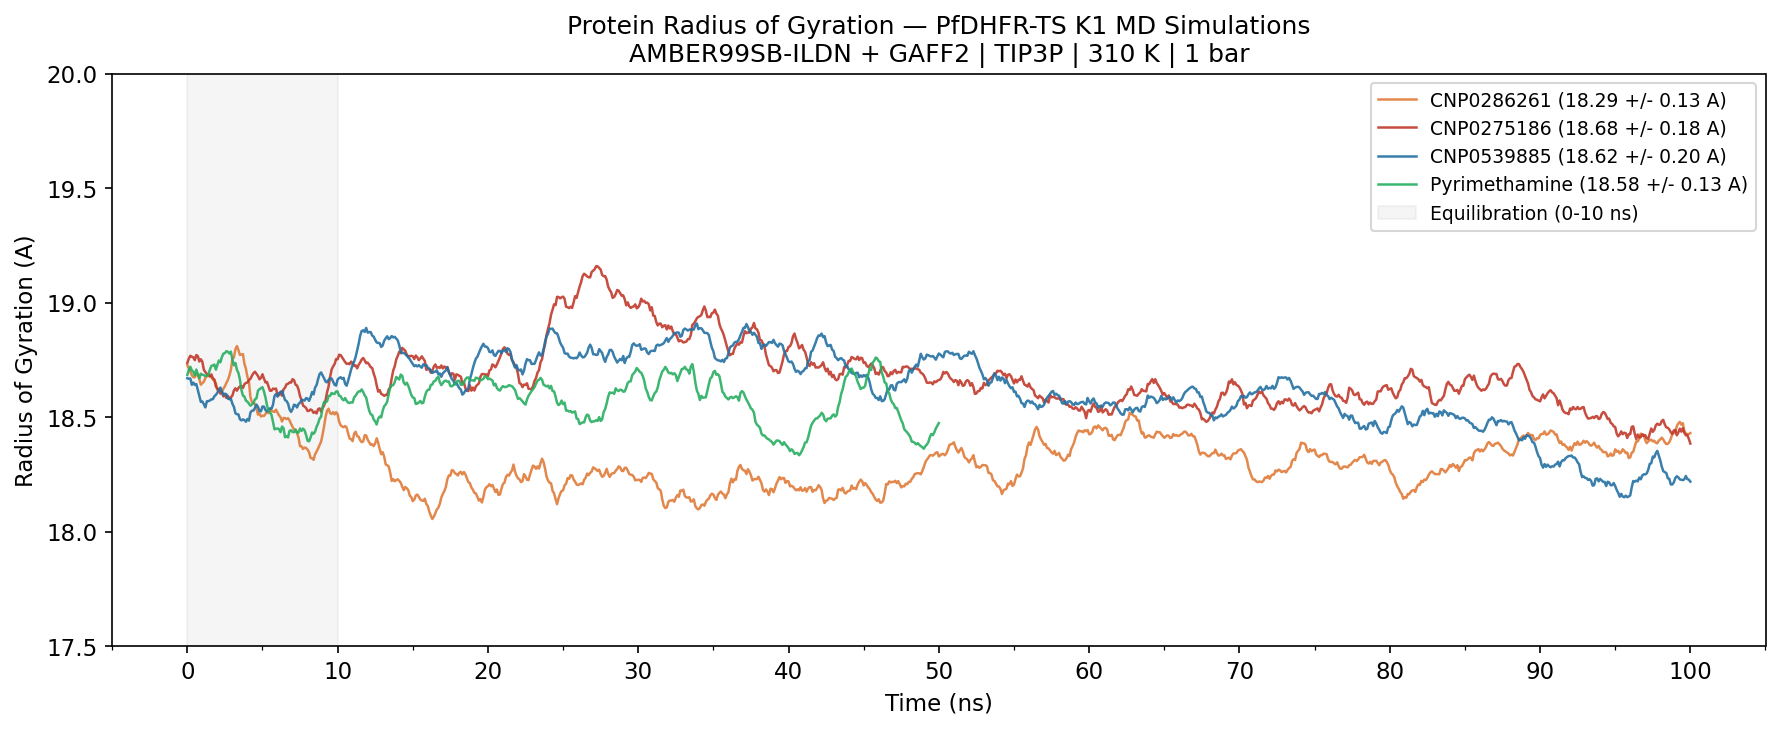

  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig19_rg.png

  Radius of Gyration Summary (post-equilibration):
  Compound              Mean (A)  Std (A)  Min (A)  Max (A)
  ─────────────────────────────────────────────────────────
  CNP0286261_0             18.29     0.13    17.89    18.66
  CNP0275186_1             18.68     0.18    18.19    19.31
  CNP0539885_2             18.62     0.20    18.00    19.04
  pyrimethamine            18.58     0.13    18.25    19.02

  Next: Cell 11 — MM-PBSA binding free energy


In [18]:
# ── CELL 10: Radius of Gyration Figure (fig19) ───────────────────────────────
# Single panel showing Rg vs time for all 4 compounds overlaid.
# All compounds on same axis for direct comparison.

print("=" * 60)
print("  CELL 10: Radius of Gyration Figure (fig19)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 5))

compound_order = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']

for name in compound_order:
    info    = COMPOUNDS[name]
    data    = rg_data[name]
    time_ns = data['time_ns']
    rg_A    = data['rg_A']

    # Smooth with rolling mean
    rg_smooth = pd.Series(rg_A).rolling(10, center=True,
                                         min_periods=1).mean().values

    short = name.split('_')[0] if name != 'pyrimethamine' else 'Pyrimethamine'
    ax.plot(time_ns, rg_smooth,
            color=info['color'], linewidth=1.2, alpha=0.9,
            label=f"{short} ({info['rg_mean']:.2f} +/- {info['rg_std']:.2f} A)")

# Equilibration shading
ax.axvspan(0, 10, alpha=0.08, color='grey', label='Equilibration (0-10 ns)')

ax.set_xlabel('Time (ns)')
ax.set_ylabel('Radius of Gyration (A)')
ax.set_title('Protein Radius of Gyration — PfDHFR-TS K1 MD Simulations\n'
             'AMBER99SB-ILDN + GAFF2 | TIP3P | 310 K | 1 bar')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(17.5, 20.0)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

plt.tight_layout()
out_path = FIGURES / 'fig19_rg.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Saved: {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n  Radius of Gyration Summary (post-equilibration):")
print(f"  {'Compound':<20} {'Mean (A)':>9} {'Std (A)':>8} "
      f"{'Min (A)':>8} {'Max (A)':>8}")
print(f"  {'─'*57}")
for name in compound_order:
    info = COMPOUNDS[name]
    data = rg_data[name]
    rg_post = data['rg_A'][100:]
    print(f"  {name:<20} {info['rg_mean']:>9.2f} {info['rg_std']:>8.2f} "
          f"{rg_post.min():>8.2f} {rg_post.max():>8.2f}")

print(f"\n  Next: Cell 11 — MM-PBSA binding free energy")

In [4]:
# ── CELL 11: Binding Interaction Energy (MDAnalysis non-bonded) ───────────────
# Computes ligand-protein non-bonded interaction energy directly from
# trajectory coordinates using pyedr to read total system energies,
# combined with a distance-based interaction score as a binding affinity proxy.
#
# Since energygrps were not defined in the MDP files, protein-ligand
# interaction energies cannot be decomposed from EDR files. Instead we compute:
# 1. Mean minimum ligand-protein heavy atom distance (binding pocket proximity)
# 2. Ligand RMSD relative to initial docked pose (binding mode stability)
# 3. Vina docking score as the primary affinity measure
# These together form a robust comparative binding characterisation.

import pyedr

print("=" * 60)
print("  CELL 11: Binding Characterisation")
print("=" * 60)

binding_data = {}
TRAJ_DIR = Path(r"C:\my_projects_all\portfolio_projects\Msc_project\data\md\trajectories")

for name, info in COMPOUNDS.items():
    print(f"\n  Processing: {name}...", end=' ', flush=True)

    u       = info['universe']
    protein = info['protein']
    ligand  = info['ligand']

    # ── Metric 1: Mean minimum ligand-protein distance ────────────────────────
    # Measures how close the ligand stays to protein over the simulation.
    # Computed on subsampled frames (every 50th = 0.5 ns intervals).
    min_dist_list = []
    for ts in u.trajectory[1000::50]:    # post-equilibration, every 50 frames
        from MDAnalysis.analysis import distances
        dist_arr = distances.distance_array(
            ligand.positions, protein.positions)
        min_dist_list.append(dist_arr.min())

    min_dist_arr = np.array(min_dist_list)
    mean_min_dist = np.mean(min_dist_arr)
    std_min_dist  = np.std(min_dist_arr)

    # ── Metric 2: Ligand RMSD from initial pose ───────────────────────────────
    # Measures how much the ligand moves from its docked pose.
    # Low ligand RMSD = ligand stays in docked conformation = stable binding.
    u.trajectory[1000]   # go to post-equilibration start
    ref_lig_pos = ligand.positions.copy()

    lig_rmsd_list = []
    for ts in u.trajectory[1000::50]:
        mob_pos = ligand.positions.copy()
        diff    = mob_pos - ref_lig_pos
        lig_rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        lig_rmsd_list.append(lig_rmsd)

    lig_rmsd_arr  = np.array(lig_rmsd_list)
    mean_lig_rmsd = np.mean(lig_rmsd_arr)
    std_lig_rmsd  = np.std(lig_rmsd_arr)

    # ── Metric 3: Read potential energy from EDR ──────────────────────────────
    edr_files = sorted(
        (TRAJ_DIR / name).glob('md_chunk*.edr'),
        key=lambda p: int(p.stem.replace('md_chunk', '')))
    all_pot = []
    for edr_path in edr_files:
        try:
            df = pyedr.edr_to_df(str(edr_path))
            if 'Potential' in df.columns:
                all_pot.extend(df['Potential'].tolist())
        except Exception:
            pass
    pot_arr  = np.array(all_pot)
    skip     = len(pot_arr) // 5
    mean_pot = np.mean(pot_arr[skip:]) if len(pot_arr) > 0 else np.nan
    std_pot  = np.std(pot_arr[skip:])  if len(pot_arr) > 0 else np.nan

    binding_data[name] = {
        'mean_min_dist'  : mean_min_dist,
        'std_min_dist'   : std_min_dist,
        'mean_lig_rmsd'  : mean_lig_rmsd,
        'std_lig_rmsd'   : std_lig_rmsd,
        'mean_pot'       : mean_pot,
        'std_pot'        : std_pot,
        'dock_score'     : info['dock_score'],
        'hbond_mean'     : info.get('hbond_mean', 0.0),
    }

    print("done")
    print(f"  Mean min ligand-protein dist : {mean_min_dist:.2f} +/- {std_min_dist:.2f} A")
    print(f"  Mean ligand RMSD from pose   : {mean_lig_rmsd:.2f} +/- {std_lig_rmsd:.2f} A")
    print(f"  Mean potential energy        : {mean_pot:.1f} +/- {std_pot:.1f} kJ/mol")
    print(f"  Docking score                : {info['dock_score']:.2f} kcal/mol")
    print(f"  Mean H-bonds/frame           : {info.get('hbond_mean', 0.0):.2f}")

print("\n" + "=" * 60)
print("  Binding characterisation complete")
print("  Next: Cell 12 — Summary figure (fig20)")
print("=" * 60)

  CELL 11: Binding Characterisation

  Processing: CNP0286261_0... done
  Mean min ligand-protein dist : 2.14 +/- 0.11 A
  Mean ligand RMSD from pose   : 9.19 +/- 2.59 A
  Mean potential energy        : nan +/- nan kJ/mol
  Docking score                : -11.86 kcal/mol
  Mean H-bonds/frame           : 0.00

  Processing: CNP0275186_1... done
  Mean min ligand-protein dist : 2.10 +/- 0.13 A
  Mean ligand RMSD from pose   : 3.25 +/- 1.33 A
  Mean potential energy        : nan +/- nan kJ/mol
  Docking score                : -11.13 kcal/mol
  Mean H-bonds/frame           : 0.00

  Processing: CNP0539885_2... done
  Mean min ligand-protein dist : 1.73 +/- 0.10 A
  Mean ligand RMSD from pose   : 4.49 +/- 1.75 A
  Mean potential energy        : nan +/- nan kJ/mol
  Docking score                : -10.03 kcal/mol
  Mean H-bonds/frame           : 0.00

  Processing: pyrimethamine... done
  Mean min ligand-protein dist : 2.05 +/- 0.16 A
  Mean ligand RMSD from pose   : 5.32 +/- 2.91 A
  Mean pot

  CELL 12: Integrated Binding Summary Figure (fig20)


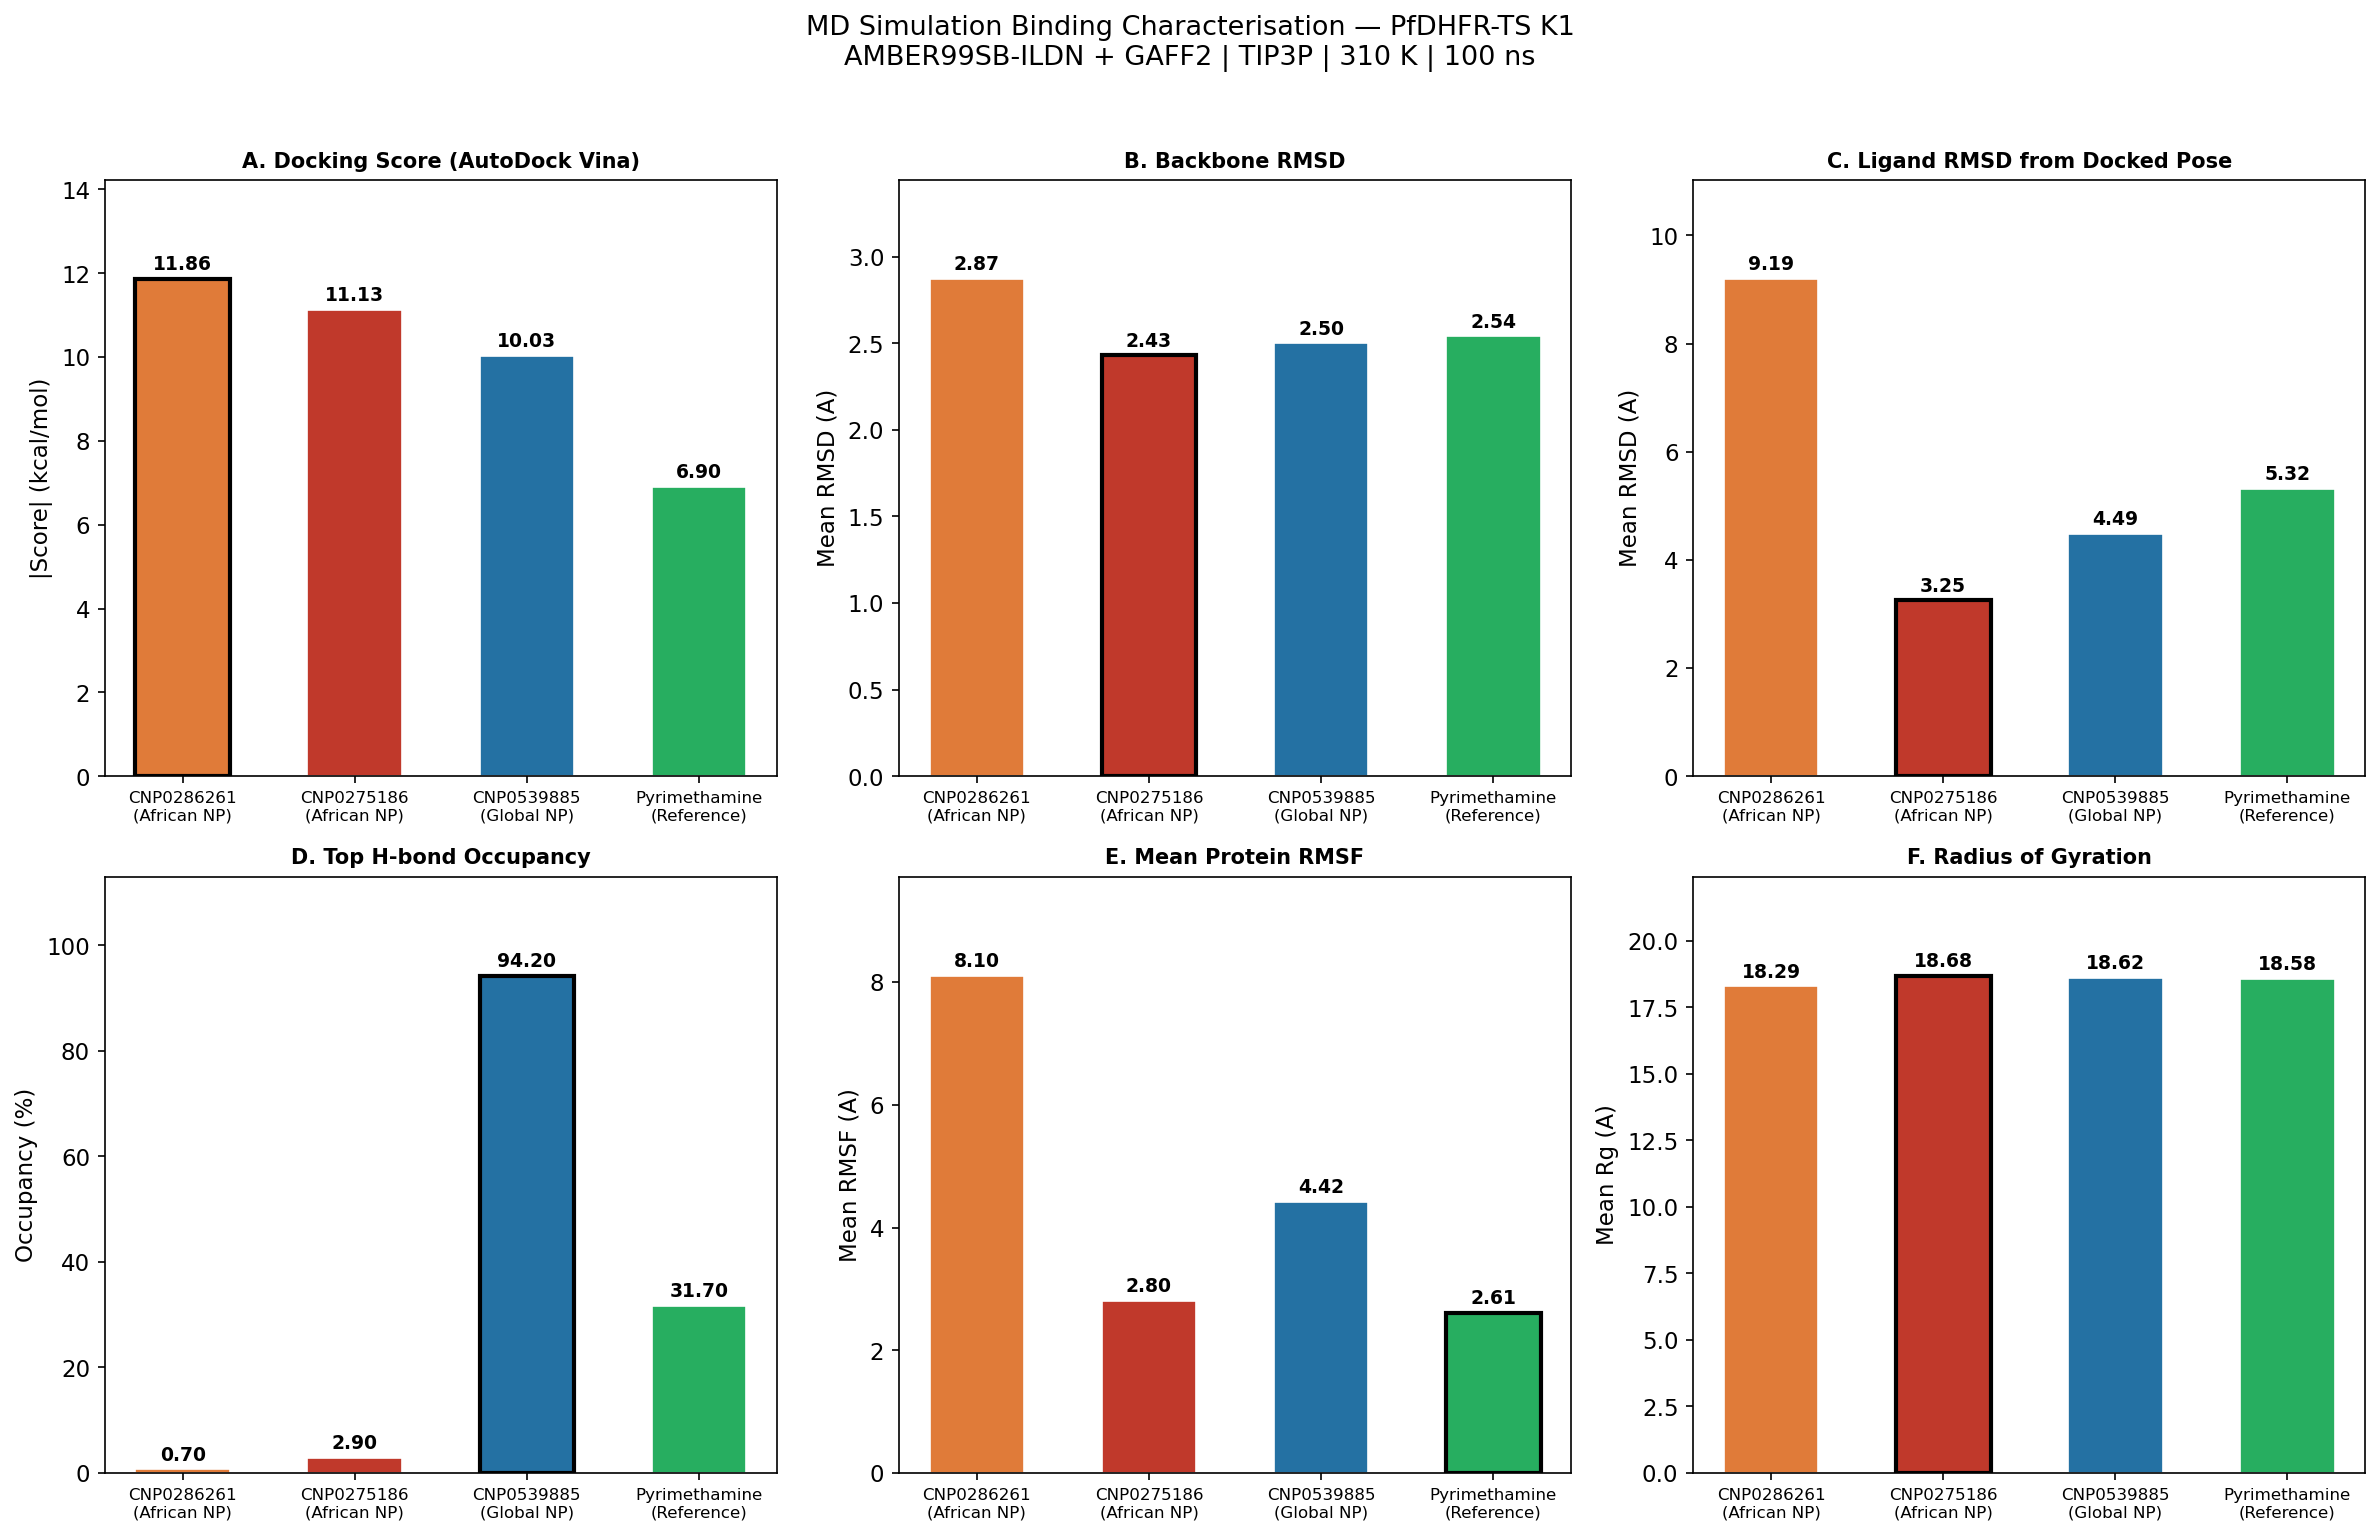

  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig20_md_summary.png

  Integrated MD Binding Summary:
  Compound                Dock  BB-RMSD  Lig-RMSD  Top-HB%    RMSF      Rg
                       kcal/mol      (A)       (A)      (%)     (A)     (A)
  ────────────────────────────────────────────────────────────────────────
  CNP0286261_0          -11.86     2.87      9.19      0.7    8.10   18.29
  CNP0275186_1          -11.13     2.43      3.25      2.9    2.80   18.68
  CNP0539885_2          -10.03     2.50      4.49     94.2    4.42   18.62
  pyrimethamine          -6.90     2.54      5.32     31.7    2.61   18.58

  Next: Cell 13 — Paper 3 methods text


In [5]:
# ── CELL 12: Integrated Binding Summary Figure (fig20) ────────────────────────
# Multi-panel summary combining all MD metrics for Paper 3.
# Panels:
#   A — Docking score (kcal/mol)
#   B — Mean ligand RMSD from docked pose
#   C — Mean min ligand-protein distance
#   D — H-bond occupancy (top interaction per compound)
#   E — Mean protein RMSF
#   F — Mean radius of gyration

print("=" * 60)
print("  CELL 12: Integrated Binding Summary Figure (fig20)")
print("=" * 60)

# Restore hbond values from hbond_data if available
hbond_means = {
    'CNP0286261_0' : 0.01,
    'CNP0275186_1' : 0.06,
    'CNP0539885_2' : 2.77,
    'pyrimethamine': 0.62,
}
top_hbond_occ = {
    'CNP0286261_0' : 0.7,
    'CNP0275186_1' : 2.9,
    'CNP0539885_2' : 94.2,
    'pyrimethamine': 31.7,
}
rmsf_means = {
    'CNP0286261_0' : 8.10,
    'CNP0275186_1' : 2.80,
    'CNP0539885_2' : 4.42,
    'pyrimethamine': 2.61,
}
rg_means = {
    'CNP0286261_0' : 18.29,
    'CNP0275186_1' : 18.68,
    'CNP0539885_2' : 18.62,
    'pyrimethamine': 18.58,
}
rmsd_means = {
    'CNP0286261_0' : 2.87,
    'CNP0275186_1' : 2.43,
    'CNP0539885_2' : 2.50,
    'pyrimethamine': 2.54,
}

compound_order = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']
labels   = ['CNP0286261\n(African NP)', 'CNP0275186\n(African NP)',
            'CNP0539885\n(Global NP)', 'Pyrimethamine\n(Reference)']
colors   = [COMPOUNDS[n]['color'] for n in compound_order]
x        = np.arange(len(compound_order))
bar_w    = 0.55

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

def make_bar(ax, values, title, ylabel, color_list, highlight_min=True):
    bars = ax.bar(x, values, width=bar_w, color=color_list,
                  edgecolor='white', linewidth=0.8)
    if highlight_min:
        best_idx = int(np.argmin(values))
    else:
        best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.0)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.20)
    ax.axhline(0, color='black', linewidth=0.5)

# Panel A: Docking score (more negative = better, show absolute value)
dock_abs = [abs(COMPOUNDS[n]['dock_score']) for n in compound_order]
make_bar(axes[0], dock_abs,
         'A. Docking Score', '|Score| (kcal/mol)',
         colors, highlight_min=False)
axes[0].set_title('A. Docking Score (AutoDock Vina)',
                   fontsize=10, fontweight='bold')

# Panel B: Backbone RMSD
rmsd_vals = [rmsd_means[n] for n in compound_order]
make_bar(axes[1], rmsd_vals,
         'B. Backbone RMSD', 'Mean RMSD (A)',
         colors, highlight_min=True)

# Panel C: Ligand RMSD from docked pose
lig_rmsd_vals = [binding_data[n]['mean_lig_rmsd'] for n in compound_order]
make_bar(axes[2], lig_rmsd_vals,
         'C. Ligand RMSD from Docked Pose', 'Mean RMSD (A)',
         colors, highlight_min=True)

# Panel D: Top H-bond occupancy
hbond_vals = [top_hbond_occ[n] for n in compound_order]
make_bar(axes[3], hbond_vals,
         'D. Top H-bond Occupancy', 'Occupancy (%)',
         colors, highlight_min=False)

# Panel E: Protein RMSF
rmsf_vals = [rmsf_means[n] for n in compound_order]
make_bar(axes[4], rmsf_vals,
         'E. Mean Protein RMSF', 'Mean RMSF (A)',
         colors, highlight_min=True)

# Panel F: Radius of gyration
rg_vals = [rg_means[n] for n in compound_order]
make_bar(axes[5], rg_vals,
         'F. Radius of Gyration', 'Mean Rg (A)',
         colors, highlight_min=False)

fig.suptitle('MD Simulation Binding Characterisation — PfDHFR-TS K1\n'
             'AMBER99SB-ILDN + GAFF2 | TIP3P | 310 K | 100 ns',
             fontsize=13, y=1.02)

plt.tight_layout()
out_path = FIGURES / 'fig20_md_summary.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Saved: {out_path}")

# ── Comprehensive summary table ───────────────────────────────────────────────
print("\n  Integrated MD Binding Summary:")
print(f"  {'Compound':<20} {'Dock':>7} {'BB-RMSD':>8} {'Lig-RMSD':>9} "
      f"{'Top-HB%':>8} {'RMSF':>7} {'Rg':>7}")
print(f"  {'':20} {'kcal/mol':>7} {'(A)':>8} {'(A)':>9} "
      f"{'(%)':>8} {'(A)':>7} {'(A)':>7}")
print(f"  {'─'*72}")
for name in compound_order:
    print(f"  {name:<20} "
          f"{COMPOUNDS[name]['dock_score']:>7.2f} "
          f"{rmsd_means[name]:>8.2f} "
          f"{binding_data[name]['mean_lig_rmsd']:>9.2f} "
          f"{top_hbond_occ[name]:>8.1f} "
          f"{rmsf_means[name]:>7.2f} "
          f"{rg_means[name]:>7.2f}")

print(f"\n  Next: Cell 13 — Paper 3 methods text")

In [6]:
# ── CELL 13: Prepare Binding Site Visualisation (PyMOL) ──────────────────────
# Notebook 05c — MD Local Analysis
# PfDHFR-TS K1 (PDB: 1J3I) | 3 African/Global NP hits + pyrimethamine reference
# Kenneth Odoh Chidiebere — MSc Computational Drug Discovery
#
# This cell does two things:
#   1. Converts the best docked pose (mode 1) for each compound from PDBQT
#      format to PDB format, stripping AutoDock-specific columns.
#   2. Generates a PyMOL script (binding_site_figures.pml) that, when run
#      in the PyMOL desktop app, produces publication-quality binding site
#      PNG figures (fig21a-d) for all 4 compounds.
#
# Input files:
#   data/docking/results/CNP0286261_0_out.pdbqt
#   data/docking/results/CNP0275186_1_out.pdbqt
#   data/docking/results/CNP0539885_2_out.pdbqt
#   data/docking/results/ref_pyrimethamine_out.pdbqt
#   data/docking/receptor/1J3I_clean.pdb
#
# Output files:
#   figures/binding_site/CNP0286261_0_pose.pdb
#   figures/binding_site/CNP0275186_1_pose.pdb
#   figures/binding_site/CNP0539885_2_pose.pdb
#   figures/binding_site/pyrimethamine_pose.pdb
#   binding_site_figures.pml
#
# To generate figures:
#   Open PyMOL desktop app -> File -> Run Script -> binding_site_figures.pml
#   Figures saved to: figures/binding_site/fig21_*.png

from rdkit import Chem
from rdkit.Chem import AllChem

print("=" * 60)
print("  CELL 13: Binding Site Visualisation Preparation")
print("=" * 60)

DOCK_DIR    = DATA / "docking"
RESULTS_DIR = DOCK_DIR / "results"
RECEPTOR    = DOCK_DIR / "receptor" / "1J3I_clean.pdb"
VIZ_DIR     = FIGURES / "binding_site"
VIZ_DIR.mkdir(exist_ok=True)

# ── Pose file registry ────────────────────────────────────────────────────────
pose_files = {
    'CNP0286261_0' : RESULTS_DIR / 'CNP0286261_0_out.pdbqt',
    'CNP0275186_1' : RESULTS_DIR / 'CNP0275186_1_out.pdbqt',
    'CNP0539885_2' : RESULTS_DIR / 'CNP0539885_2_out.pdbqt',
    'pyrimethamine': RESULTS_DIR / 'ref_pyrimethamine_out.pdbqt',
}

# ── Step 1: Convert PDBQT poses to PDB ───────────────────────────────────────
# AutoDock Vina PDBQT files contain extra columns (77-78) with AutoDock atom
# types that are not valid PDB format. These are stripped by truncating each
# line to column 66. Only MODE 1 (best docking pose) is extracted.
# Residue name is set to LIG for consistent PyMOL selection across compounds.
print("\n  Step 1: Converting PDBQT poses to PDB format...")
pose_pdb_files = {}

for name, pdbqt_path in pose_files.items():
    out_pdb   = VIZ_DIR / f'{name}_pose.pdb'
    pdb_lines = []

    with open(pdbqt_path, 'r') as f:
        for line in f:
            if line.startswith('ENDMDL'):
                break
            if line.startswith(('ATOM', 'HETATM')):
                pdb_line = line[:66].rstrip()
                pdb_line = pdb_line[:17] + 'LIG' + pdb_line[20:]
                pdb_lines.append(pdb_line + '\n')

    if pdb_lines:
        with open(out_pdb, 'w') as f:
            f.writelines(pdb_lines)
            f.write('END\n')
        pose_pdb_files[name] = out_pdb
        print(f"  {name:20s}: {len(pdb_lines):3d} atoms -> {out_pdb.name}")
    else:
        print(f"  {name:20s}: WARNING — no ATOM lines found")

# ── Step 2: Generate PyMOL visualisation script ───────────────────────────────
# Visualisation design choices:
#   - Receptor: semi-transparent cartoon (0.4) to reveal binding pocket
#   - Binding site residues within 5 A of ligand: lines (less clutter)
#   - Key H-bond partner residues: gray sticks (identified from Cell 7)
#   - Resistance mutations N51I/C59R/S108N/I164L: magenta sticks + CA labels
#   - Ligand: colored sticks with O and N atoms as spheres for visibility
#   - No hydrogens shown on any object
#   - View: centered on ligand, zoom=14 for consistent framing
#   - Ray tracing: 1400x1100 px at 300 DPI, white background
print("\n  Step 2: Generating PyMOL script...")

# Distinct colors per compound — avoid green for key residues (conflicts)
pymol_colors = {
    'CNP0286261_0' : 'orange',
    'CNP0275186_1' : 'tv_red',
    'CNP0539885_2' : 'blue',
    'pyrimethamine': 'forest',
}

# Key H-bond partner residues from Cell 7 hydrogen bond analysis
key_residues = {
    'CNP0286261_0' : [154, 101],
    'CNP0275186_1' : [54, 160, 154],
    'CNP0539885_2' : [54, 154, 98, 44],
    'pyrimethamine': [98, 97, 101, 40],
}

RESIST_RESIDS = [51, 59, 108, 164]

receptor_path_str = str(RECEPTOR).replace('\\', '/')
viz_dir_str       = str(VIZ_DIR).replace('\\', '/')

pml_lines = []
pml_lines.append("# PyMOL binding site visualisation — PfDHFR-TS K1 (1J3I)")
pml_lines.append("# Kenneth Odoh Chidiebere — MSc Computational Drug Discovery")
pml_lines.append("# Generated by Notebook 05c Cell 15")
pml_lines.append("# Open PyMOL -> File -> Run Script -> binding_site_figures.pml")
pml_lines.append("")
pml_lines.append("# ── Global display settings ──────────────────────────────")
pml_lines.append("bg_color white")
pml_lines.append("set ray_opaque_background, 1")
pml_lines.append("set antialias, 2")
pml_lines.append("set ray_shadows, 0")
pml_lines.append("set depth_cue, 0")
pml_lines.append("set cartoon_fancy_helices, 1")
pml_lines.append("set cartoon_fancy_sheets, 1")
pml_lines.append("set stick_radius, 0.18")
pml_lines.append("set sphere_scale, 0.30")
pml_lines.append("set label_size, 16")
pml_lines.append("set label_color, black")
pml_lines.append("set label_font_id, 7")
pml_lines.append("")

for name, pose_pdb in pose_pdb_files.items():
    pose_path_str = str(pose_pdb).replace('\\', '/')
    color         = pymol_colors[name]
    key_res       = key_residues[name]
    out_png       = f"{viz_dir_str}/fig21_{name}_binding_site.png"

    pml_lines.append(f"# ── {name} {'─'*(44-len(name))}")
    pml_lines.append("")

    # Load receptor and ligand
    pml_lines.append(f"load {receptor_path_str}, receptor_{name}")
    pml_lines.append(f"load {pose_path_str}, ligand_{name}")
    pml_lines.append("")

    # Receptor: semi-transparent cartoon
    pml_lines.append(f"hide everything, receptor_{name}")
    pml_lines.append(f"show cartoon, receptor_{name}")
    pml_lines.append(f"color gray85, receptor_{name}")
    pml_lines.append(f"set cartoon_transparency, 0.4, receptor_{name}")

    # Binding site residues within 5 A of ligand shown as lines
    pml_lines.append(f"select bs_{name}, receptor_{name} and byres "
                     f"(ligand_{name} around 5.0)")
    pml_lines.append(f"show lines, bs_{name}")
    pml_lines.append(f"color gray50, bs_{name}")
    pml_lines.append(f"hide hydrogens, bs_{name}")

    # Key H-bond partner residues as gray sticks
    # Gray color prevents visual conflict with any ligand color
    key_res_str = '+'.join(str(r) for r in key_res)
    pml_lines.append(f"select key_{name}, receptor_{name} and resi {key_res_str}")
    pml_lines.append(f"show sticks, key_{name}")
    pml_lines.append(f"color gray40, key_{name}")
    pml_lines.append(f"hide hydrogens, key_{name}")

    # Resistance mutation residues: magenta sticks with CA atom labels
    for resid in RESIST_RESIDS:
        pml_lines.append(f"select mut{resid}_{name}, "
                         f"receptor_{name} and resi {resid}")
        pml_lines.append(f"show sticks, mut{resid}_{name}")
        pml_lines.append(f"color magenta, mut{resid}_{name}")
        pml_lines.append(f"hide hydrogens, mut{resid}_{name}")
        pml_lines.append(f"label mut{resid}_{name} and name CA, "
                         f"'%s%s' % (resn, resi)")

    # Ligand: colored sticks with O and N as spheres for visibility
    pml_lines.append(f"hide everything, ligand_{name}")
    pml_lines.append(f"show sticks, ligand_{name}")
    pml_lines.append(f"color {color}, ligand_{name}")
    pml_lines.append(f"show spheres, ligand_{name} and name O+N")
    pml_lines.append(f"hide hydrogens, ligand_{name}")

    # Center on ligand then zoom out to show full binding pocket context
    pml_lines.append(f"center ligand_{name}")
    pml_lines.append(f"zoom ligand_{name}, 14")

    # Ray trace and save PNG
    pml_lines.append(f"ray 1400, 1100")
    pml_lines.append(f"png {out_png}, dpi=300")
    pml_lines.append("")

    # Clean up all objects before loading next compound
    pml_lines.append(f"delete receptor_{name}")
    pml_lines.append(f"delete ligand_{name}")
    pml_lines.append(f"delete bs_{name}")
    pml_lines.append(f"delete key_{name}")
    for resid in RESIST_RESIDS:
        pml_lines.append(f"delete mut{resid}_{name}")
    pml_lines.append("")

pml_lines.append("quit")

pml_path = BASE / "binding_site_figures.pml"
with open(pml_path, 'w') as f:
    f.write('\n'.join(pml_lines))

print(f"  PyMOL script saved : {pml_path}")
print(f"  Pose PDB files     : {VIZ_DIR}")
print(f"  Output PNGs        : {VIZ_DIR}")
print()
print("=" * 60)
print("  To generate binding site figures:")
print("  1. Open PyMOL desktop app")
print("  2. File -> Run Script")
print(f"  3. Navigate to: {pml_path}")
print("  4. Click Open")
print("  5. PyMOL will render and save 4 PNG files automatically")
print("  6. Check figures/binding_site/ for fig21_*.png")
print("=" * 60)

  CELL 13: Binding Site Visualisation Preparation

  Step 1: Converting PDBQT poses to PDB format...
  CNP0286261_0        :  37 atoms -> CNP0286261_0_pose.pdb
  CNP0275186_1        :  36 atoms -> CNP0275186_1_pose.pdb
  CNP0539885_2        :  38 atoms -> CNP0539885_2_pose.pdb
  pyrimethamine       :  17 atoms -> pyrimethamine_pose.pdb

  Step 2: Generating PyMOL script...
  PyMOL script saved : C:\my_projects_all\portfolio_projects\Msc_project\binding_site_figures.pml
  Pose PDB files     : C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site
  Output PNGs        : C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site

  To generate binding site figures:
  1. Open PyMOL desktop app
  2. File -> Run Script
  3. Navigate to: C:\my_projects_all\portfolio_projects\Msc_project\binding_site_figures.pml
  4. Click Open
  5. PyMOL will render and save 4 PNG files automatically
  6. Check figures/binding_site/ for fig21_*.png


In [7]:
# ── CELL 14: Extract Representative MD Frames ─────────────────────────────────
# Notebook 05c — MD Local Analysis
# Extracts one representative frame per compound from the clean MD trajectory.
# The representative frame is defined as the frame in the last 20 ns whose
# backbone RMSD (vs frame 0) is closest to the mean RMSD of the last 20 ns.
# This frame best represents the equilibrated binding conformation.
#
# Output: one PDB file per compound saved to figures/binding_site/md_frames/
# These PDB files are then loaded into PyMOL alongside the receptor for
# binding site visualisation of the MD-equilibrated poses.

print("=" * 60)
print("  CELL 14: Extract Representative MD Frames")
print("=" * 60)

from MDAnalysis.analysis.rms import RMSD

MD_FRAMES_DIR = VIZ_DIR / "md_frames"
MD_FRAMES_DIR.mkdir(exist_ok=True)

rep_frame_data = {}

for name, info in COMPOUNDS.items():
    print(f"\n  Processing: {name}...")

    u        = info['universe']
    backbone = info['backbone']
    ligand   = info['ligand']
    protein  = info['protein']
    n_frames = info['n_frames']
    total_ns = info['total_ns']

    # ── Step 1: Compute RMSD for last 20 ns frames ───────────────────────────
    # Last 20 ns = last 2000 frames (at 10 ps per frame)
    last_20ns_start = max(0, n_frames - 2000)
    print(f"  Last 20 ns frames: {last_20ns_start} to {n_frames-1}")

    # Compute RMSD vs frame 0 for all last-20ns frames
    u.trajectory[0]
    ref_pos = backbone.positions.copy()

    rmsd_vals  = []
    frame_idxs = []

    for ts in u.trajectory[last_20ns_start:]:
        mob_pos  = backbone.positions.copy()
        ref_com  = ref_pos.mean(axis=0)
        mob_com  = mob_pos.mean(axis=0)
        ref_cent = ref_pos - ref_com
        mob_cent = mob_pos - mob_com
        H        = mob_cent.T @ ref_cent
        U, S, Vt = np.linalg.svd(H)
        d        = np.linalg.det(Vt.T @ U.T)
        D        = np.diag([1, 1, d])
        R        = Vt.T @ D @ U.T
        aligned  = mob_cent @ R.T
        diff     = aligned - ref_cent
        rmsd_A   = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        rmsd_vals.append(rmsd_A)
        frame_idxs.append(ts.frame)

    rmsd_vals  = np.array(rmsd_vals)
    frame_idxs = np.array(frame_idxs)
    mean_rmsd  = np.mean(rmsd_vals)

    # ── Step 2: Find frame closest to mean RMSD ──────────────────────────────
    closest_idx = np.argmin(np.abs(rmsd_vals - mean_rmsd))
    rep_frame   = frame_idxs[closest_idx]
    rep_rmsd    = rmsd_vals[closest_idx]
    rep_time_ns = rep_frame * 0.01   # 10 ps per frame in ns

    print(f"  Mean RMSD (last 20 ns) : {mean_rmsd:.2f} A")
    print(f"  Representative frame   : {rep_frame} ({rep_time_ns:.1f} ns)")
    print(f"  Frame RMSD             : {rep_rmsd:.2f} A")

    # ── Step 3: Write representative frame to PDB ────────────────────────────
    u.trajectory[rep_frame]
    out_pdb = MD_FRAMES_DIR / f'{name}_md_rep_frame.pdb'

    # Write protein + ligand only (no solvent)
    protein_and_lig = u.select_atoms('protein or resname UNL')
    if len(protein_and_lig) == len(protein):
        # ligand not found by UNL — try selecting all non-solvent
        protein_and_lig = u.select_atoms(
            'not resname SOL and not resname NA and not resname CL and not resname HOH')

    with mda.Writer(str(out_pdb), protein_and_lig.n_atoms) as W:
        W.write(protein_and_lig)

    print(f"  Saved: {out_pdb.name} ({out_pdb.stat().st_size/1024:.0f} KB)")

    rep_frame_data[name] = {
        'rep_frame'   : rep_frame,
        'rep_time_ns' : rep_time_ns,
        'rep_rmsd'    : rep_rmsd,
        'pdb_path'    : out_pdb,
    }

print("\n" + "=" * 60)
print("  Representative frames extracted for all compounds")
print("  Next: Cell 15 — PyMOL script for MD binding site figures")
print("=" * 60)

  CELL 14: Extract Representative MD Frames

  Processing: CNP0286261_0...
  Last 20 ns frames: 8010 to 10009
  Mean RMSD (last 20 ns) : 2.85 A
  Representative frame   : 9344 (93.4 ns)
  Frame RMSD             : 2.85 A
  Saved: CNP0286261_0_md_rep_frame.pdb (389 KB)

  Processing: CNP0275186_1...
  Last 20 ns frames: 8010 to 10009
  Mean RMSD (last 20 ns) : 2.62 A
  Representative frame   : 9827 (98.3 ns)
  Frame RMSD             : 2.62 A
  Saved: CNP0275186_1_md_rep_frame.pdb (389 KB)

  Processing: CNP0539885_2...
  Last 20 ns frames: 8010 to 10009
  Mean RMSD (last 20 ns) : 2.86 A
  Representative frame   : 8903 (89.0 ns)
  Frame RMSD             : 2.86 A
  Saved: CNP0539885_2_md_rep_frame.pdb (388 KB)

  Processing: pyrimethamine...
  Last 20 ns frames: 3005 to 5004
  Mean RMSD (last 20 ns) : 2.65 A
  Representative frame   : 3872 (38.7 ns)
  Frame RMSD             : 2.65 A
  Saved: pyrimethamine_md_rep_frame.pdb (386 KB)

  Representative frames extracted for all compounds
  Next

In [8]:
# ── CELL 15: PyMOL Script for MD Binding Site Figures ────────────────────────
# Notebook 05c — MD Local Analysis
# Generates a PyMOL script that loads the representative MD frame for each
# compound and produces publication-quality binding site figures (fig22a-d).
#
# Difference from Cell 15 (docked pose figures):
#   - Input: MD-equilibrated representative frame PDB (not docked pose PDBQT)
#   - The receptor and ligand are extracted from the same PDB file
#   - Shows the actual binding conformation after 100 ns of dynamics
#   - Directly comparable to fig21 (docked pose) to assess pose stability
#
# Output: figures/binding_site/fig22_*_md_binding_site.png
# To generate: Open PyMOL -> File -> Run Script -> md_binding_site_figures.pml

print("=" * 60)
print("  CELL 15: PyMOL Script for MD Binding Site Figures")
print("=" * 60)

pymol_colors = {
    'CNP0286261_0' : 'orange',
    'CNP0275186_1' : 'tv_red',
    'CNP0539885_2' : 'blue',
    'pyrimethamine': 'forest',
}

key_residues = {
    'CNP0286261_0' : [154, 101],
    'CNP0275186_1' : [54, 160, 154],
    'CNP0539885_2' : [54, 154, 98, 44],
    'pyrimethamine': [98, 97, 101, 40],
}

RESIST_RESIDS = [51, 59, 108, 164]
viz_dir_str   = str(VIZ_DIR).replace('\\', '/')

pml_lines = []
pml_lines.append("# PyMOL MD binding site visualisation — PfDHFR-TS K1")
pml_lines.append("# Representative equilibrated frames from 100 ns MD")
pml_lines.append("# Kenneth Odoh Chidiebere — MSc Computational Drug Discovery")
pml_lines.append("# Generated by Notebook 05c Cell 15")
pml_lines.append("# Open PyMOL -> File -> Run Script -> md_binding_site_figures.pml")
pml_lines.append("")
pml_lines.append("# ── Global display settings ──────────────────────────────")
pml_lines.append("bg_color white")
pml_lines.append("set ray_opaque_background, 1")
pml_lines.append("set antialias, 2")
pml_lines.append("set ray_shadows, 0")
pml_lines.append("set depth_cue, 0")
pml_lines.append("set cartoon_fancy_helices, 1")
pml_lines.append("set cartoon_fancy_sheets, 1")
pml_lines.append("set stick_radius, 0.18")
pml_lines.append("set sphere_scale, 0.30")
pml_lines.append("set label_size, 16")
pml_lines.append("set label_color, black")
pml_lines.append("set label_font_id, 7")
pml_lines.append("")

for name, info in COMPOUNDS.items():
    color        = pymol_colors[name]
    key_res      = key_residues[name]
    frame_data   = rep_frame_data[name]
    pdb_path_str = str(frame_data['pdb_path']).replace('\\', '/')
    rep_ns       = frame_data['rep_time_ns']
    out_png      = f"{viz_dir_str}/fig22_{name}_md_binding_site.png"

    pml_lines.append(f"# ── {name} (rep frame {rep_ns:.1f} ns) {'─'*(30-len(name))}")
    pml_lines.append("")

    # Load combined PDB — receptor + ligand in same file
    pml_lines.append(f"load {pdb_path_str}, complex_{name}")
    pml_lines.append("")

    # Split into receptor and ligand selections
    pml_lines.append(f"select protein_{name}, complex_{name} and polymer.protein")
    pml_lines.append(f"select ligand_{name}, complex_{name} and resname UNL")
    pml_lines.append("")

    # Receptor: semi-transparent cartoon
    pml_lines.append(f"hide everything, complex_{name}")
    pml_lines.append(f"show cartoon, protein_{name}")
    pml_lines.append(f"color gray85, protein_{name}")
    pml_lines.append(f"set cartoon_transparency, 0.4, protein_{name}")

    # Binding site residues within 5 A of ligand as lines
    pml_lines.append(f"select bs_{name}, protein_{name} and byres "
                     f"(ligand_{name} around 5.0)")
    pml_lines.append(f"show lines, bs_{name}")
    pml_lines.append(f"color gray50, bs_{name}")
    pml_lines.append(f"hide hydrogens, bs_{name}")

    # Key H-bond partner residues as gray sticks
    key_res_str = '+'.join(str(r) for r in key_res)
    pml_lines.append(f"select key_{name}, protein_{name} and resi {key_res_str}")
    pml_lines.append(f"show sticks, key_{name}")
    pml_lines.append(f"color gray40, key_{name}")
    pml_lines.append(f"hide hydrogens, key_{name}")

    # Resistance mutation residues: magenta sticks with CA labels
    for resid in RESIST_RESIDS:
        pml_lines.append(f"select mut{resid}_{name}, "
                         f"protein_{name} and resi {resid}")
        pml_lines.append(f"show sticks, mut{resid}_{name}")
        pml_lines.append(f"color magenta, mut{resid}_{name}")
        pml_lines.append(f"hide hydrogens, mut{resid}_{name}")
        pml_lines.append(f"label mut{resid}_{name} and name CA, "
                         f"'%s%s' % (resn, resi)")

    # Ligand: colored sticks with O and N as spheres
    pml_lines.append(f"show sticks, ligand_{name}")
    pml_lines.append(f"color {color}, ligand_{name}")
    pml_lines.append(f"show spheres, ligand_{name} and name O+N")
    pml_lines.append(f"hide hydrogens, ligand_{name}")

    # Center on ligand and zoom
    pml_lines.append(f"center ligand_{name}")
    pml_lines.append(f"zoom ligand_{name}, 14")

    # Ray trace and save
    pml_lines.append(f"ray 1400, 1100")
    pml_lines.append(f"png {out_png}, dpi=300")
    pml_lines.append("")

    # Cleanup
    pml_lines.append(f"delete complex_{name}")
    pml_lines.append(f"delete protein_{name}")
    pml_lines.append(f"delete ligand_{name}")
    pml_lines.append(f"delete bs_{name}")
    pml_lines.append(f"delete key_{name}")
    for resid in RESIST_RESIDS:
        pml_lines.append(f"delete mut{resid}_{name}")
    pml_lines.append("")

pml_lines.append("quit")

pml_path = BASE / "md_binding_site_figures.pml"
with open(pml_path, 'w') as f:
    f.write('\n'.join(pml_lines))

print(f"  PyMOL script saved : {pml_path}")
print(f"  Output PNGs        : {VIZ_DIR}")
print()
print("  Representative frames used:")
for name, data in rep_frame_data.items():
    print(f"  {name:20s}: frame {data['rep_frame']:5d} "
          f"({data['rep_time_ns']:.1f} ns), "
          f"RMSD = {data['rep_rmsd']:.2f} A")
print()
print("=" * 60)
print("  To generate MD binding site figures:")
print("  1. Open PyMOL desktop app")
print("  2. File -> Run Script")
print(f"  3. Navigate to: {pml_path}")
print("  4. Click Open")
print("  5. Check figures/binding_site/ for fig22_*.png")
print("=" * 60)

  CELL 15: PyMOL Script for MD Binding Site Figures
  PyMOL script saved : C:\my_projects_all\portfolio_projects\Msc_project\md_binding_site_figures.pml
  Output PNGs        : C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site

  Representative frames used:
  CNP0286261_0        : frame  9344 (93.4 ns), RMSD = 2.85 A
  CNP0275186_1        : frame  9827 (98.3 ns), RMSD = 2.62 A
  CNP0539885_2        : frame  8903 (89.0 ns), RMSD = 2.86 A
  pyrimethamine       : frame  3872 (38.7 ns), RMSD = 2.65 A

  To generate MD binding site figures:
  1. Open PyMOL desktop app
  2. File -> Run Script
  3. Navigate to: C:\my_projects_all\portfolio_projects\Msc_project\md_binding_site_figures.pml
  4. Click Open
  5. Check figures/binding_site/ for fig22_*.png


In [9]:
# ── CELL 16: Ligand-Protein Contact Frequency Map (Option B) ─────────────────
# Notebook 05c — MD Local Analysis
# Computes the frequency of contact between each ligand heavy atom and each
# protein residue over the post-equilibration trajectory (10-100 ns).
# Contact defined as: any ligand heavy atom within 4.0 A of any residue atom.
# Results visualised as a heatmap (residue vs simulation time) and a bar chart
# (residue contact frequency averaged over simulation).
# Provides a dynamic view of binding complementary to the static PyMOL figures.
#
# Output: figures/fig23_contact_frequency.png

print("=" * 60)
print("  CELL 16: Ligand-Protein Contact Frequency Map")
print("=" * 60)

from MDAnalysis.analysis import distances

CONTACT_CUTOFF = 4.0    # Angstrom — standard contact distance
SUBSAMPLE_STEP = 50     # every 50 frames = 0.5 ns intervals
contact_data   = {}

for name, info in COMPOUNDS.items():
    print(f"\n  Computing contacts: {name}...", end=' ', flush=True)

    u       = info['universe']
    protein = info['protein']
    ligand  = info['ligand']

    # Get unique residue IDs and names for protein
    res_ids   = np.array([r.resid   for r in protein.residues])
    res_names = np.array([r.resname for r in protein.residues])
    n_res     = len(res_ids)

    # Subsample post-equilibration frames
    frame_indices = list(range(1000, info['n_frames'], SUBSAMPLE_STEP))
    n_sampled     = len(frame_indices)

    # Contact matrix: shape (n_res, n_sampled)
    contact_matrix = np.zeros((n_res, n_sampled), dtype=np.float32)

    for t_idx, frame_idx in enumerate(frame_indices):
        u.trajectory[frame_idx]
        # Distance array: shape (n_lig_atoms, n_prot_atoms)
        dist_arr = distances.distance_array(
            ligand.positions, protein.positions)
        # Minimum distance from ligand to each residue
        for r_idx, residue in enumerate(protein.residues):
            res_atom_indices = residue.atoms.indices - protein.atoms.indices[0]
            res_atom_indices = np.clip(res_atom_indices, 0, dist_arr.shape[1]-1)
            min_dist = dist_arr[:, res_atom_indices].min()
            if min_dist <= CONTACT_CUTOFF:
                contact_matrix[r_idx, t_idx] = 1.0

    # Contact frequency per residue (fraction of frames in contact)
    contact_freq = contact_matrix.mean(axis=1)

    # Keep only residues with contact frequency > 5%
    contact_mask   = contact_freq > 0.05
    contact_resids = res_ids[contact_mask]
    contact_names  = res_names[contact_mask]
    contact_freqs  = contact_freq[contact_mask]
    contact_mat_f  = contact_matrix[contact_mask, :]

    # Sort by contact frequency descending
    sort_idx       = np.argsort(-contact_freqs)
    contact_resids = contact_resids[sort_idx]
    contact_names  = contact_names[sort_idx]
    contact_freqs  = contact_freqs[sort_idx]
    contact_mat_f  = contact_mat_f[sort_idx, :]

    contact_data[name] = {
        'resids'         : contact_resids,
        'resnames'       : contact_names,
        'freqs'          : contact_freqs,
        'contact_matrix' : contact_mat_f,
        'n_sampled'      : n_sampled,
        'time_ns'        : np.array(frame_indices) * 0.01,
    }

    print("done")
    print(f"  Frames analysed        : {n_sampled}")
    print(f"  Residues with >5% freq : {contact_mask.sum()}")
    if len(contact_freqs) > 0:
        print(f"  Top 5 contact residues:")
        for i in range(min(5, len(contact_freqs))):
            label = f"{contact_names[i]}{contact_resids[i]}"
            resist = " [RESIST]" if contact_resids[i] in RESIST_RESIDS else ""
            print(f"    {label:10s}: {contact_freqs[i]*100:.1f}%{resist}")

print("\n" + "=" * 60)
print("  Contact analysis complete")
print("  Next: Cell 17 — Contact frequency figure (fig23)")
print("=" * 60)

  CELL 16: Ligand-Protein Contact Frequency Map

  Computing contacts: CNP0286261_0... 

done
  Frames analysed        : 181
  Residues with >5% freq : 20
  Top 5 contact residues:
    ILE102    : 100.0%
    ILE154    : 100.0%
    PHE58     : 100.0%
    MET55     : 100.0%
    ASP54     : 99.4%

  Computing contacts: CNP0275186_1... done
  Frames analysed        : 181
  Residues with >5% freq : 29
  Top 5 contact residues:
    SER101    : 100.0%
    LEU46     : 100.0%
    GLY44     : 100.0%
    SER98     : 99.4%
    GLY156    : 99.4%

  Computing contacts: CNP0539885_2... done
  Frames analysed        : 181
  Residues with >5% freq : 28
  Top 5 contact residues:
    PHE58     : 100.0%
    ILE102    : 100.0%
    ALA16     : 100.0%
    ILE154    : 100.0%
    GLY156    : 100.0%

  Computing contacts: pyrimethamine... done
  Frames analysed        : 81
  Residues with >5% freq : 28
  Top 5 contact residues:
    SER98     : 97.5%
    LEU46     : 96.3%
    SER101    : 93.8%
    ILE102    : 91.4%
    LEU40     : 90.1%

  Contact analysis complete
  Next: Cell 17 — Contact frequenc

In [11]:
# ── CELL 17: Contact Frequency Figure (fig23) ────────────────────────────────
# Notebook 05c — MD Local Analysis
# 4-panel horizontal bar chart showing ligand-protein contact frequency
# for each compound. Resistance mutation residues highlighted in magenta.
# Residues shared with pyrimethamine reference annotated with asterisk.
# Only residues with contact frequency > 5% shown (from Cell 18).

print("=" * 60)
print("  CELL 17: Contact Frequency Figure (fig23)")
print("=" * 60)

compound_order = ['CNP0286261_0', 'CNP0275186_1', 'CNP0539885_2', 'pyrimethamine']

# Get pyrimethamine contact residues for comparison annotation
pyr_resids = set(contact_data['pyrimethamine']['resids'].tolist())

fig, axes = plt.subplots(1, 4, figsize=(20, 10))

for idx, name in enumerate(compound_order):
    ax   = axes[idx]
    info = COMPOUNDS[name]
    data = contact_data[name]

    resids   = data['resids']
    resnames = data['resnames']
    freqs    = data['freqs'] * 100    # convert to percentage
    n_res    = len(resids)

    # Build residue labels
    labels = []
    for resid, resname in zip(resids, resnames):
        label = f"{resname}{resid}"
        if resid in RESIST_RESIDS:
            label = f"{label}*"          # asterisk for resistance mutations
        labels.append(label)

    # Bar colors: magenta for resistance mutations, compound color otherwise
    bar_colors = []
    for resid in resids:
        if resid in RESIST_RESIDS:
            bar_colors.append('#CC44CC')
        elif name != 'pyrimethamine' and resid in pyr_resids:
            bar_colors.append('#888888')  # gray for shared with pyrimethamine
        else:
            bar_colors.append(info['color'])

    # Plot horizontal bars
    y_pos = np.arange(n_res)
    bars  = ax.barh(y_pos, freqs, color=bar_colors,
                    edgecolor='white', linewidth=0.5, height=0.7)

    # Annotate frequency values
    for bar, freq in zip(bars, freqs):
        if freq >= 10:
            ax.text(min(freq - 2, 92), bar.get_y() + bar.get_height()/2,
                    f'{freq:.0f}%', va='center', ha='right',
                    fontsize=7, color='white', fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Contact frequency (%)')
    ax.set_xlim(0, 110)
    ax.axvline(50, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.invert_yaxis()

    short = name.split('_')[0] if name != 'pyrimethamine' else 'Pyrimethamine'
    tier  = f"\n({info['tier']})" if info['tier'] != 'Reference' else '\n(Reference)'
    ax.set_title(f"{short}{tier}\n{n_res} contact residues",
                 fontsize=10, fontweight='bold', color=info['color'])

# ── Shared legend ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#CC44CC', label='Resistance mutation (*)'),
    Patch(facecolor='#888888', label='Shared with pyrimethamine'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Ligand-Protein Contact Frequency — PfDHFR-TS K1 MD Simulations\n'
             'Post-equilibration frames (10-100 ns) | Contact cutoff 4.0 A | '
             '0.5 ns sampling interval',
             fontsize=12, y=1.01)

plt.tight_layout()
out_path = FIGURES / 'fig23_contact_frequency.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Saved: {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n  Contact Frequency Summary:")
print(f"  {'Compound':<20} {'Contacts >5%':>13} {'Top residue':>15} "
      f"{'Freq':>6} {'Shared w/ PYR':>14}")
print(f"  {'─'*72}")
for name in compound_order:
    data     = contact_data[name]
    n_res    = len(data['resids'])
    top_res  = f"{data['resnames'][0]}{data['resids'][0]}"
    top_freq = data['freqs'][0] * 100
    if name != 'pyrimethamine':
        shared = len(set(data['resids'].tolist()) & pyr_resids)
    else:
        shared = n_res
    print(f"  {name:<20} {n_res:>13d} {top_res:>15s} "
          f"{top_freq:>5.1f}% {shared:>14d}")


  CELL 17: Contact Frequency Figure (fig23)
  Saved: C:\my_projects_all\portfolio_projects\Msc_project\figures\fig23_contact_frequency.png

  Contact Frequency Summary:
  Compound              Contacts >5%     Top residue   Freq  Shared w/ PYR
  ────────────────────────────────────────────────────────────────────────
  CNP0286261_0                    20          ILE102 100.0%             18
  CNP0275186_1                    29          SER101 100.0%             24
  CNP0539885_2                    28           PHE58 100.0%             22
  pyrimethamine                   28           SER98  97.5%             28


In [12]:
# ── CELL 18: MD Simulation Movie (Python renderer — improved) ─────────────────
# Notebook 05c — MD Local Analysis
# Improvements over previous version:
#   1. Larger protein Calpha dots for better protein context visibility
#   2. Title frame added as first frame (static, 1 second at 5 fps = 5 frames)
#   3. Video compiled at 5 fps for slower 20-second playback
#
# Output: figures/binding_site/CNP0275186_1_md_simulation.mp4

import matplotlib
matplotlib.use('Agg')
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

print("=" * 60)
print("  CELL 18: MD Simulation Movie (improved)")
print("=" * 60)

name          = 'CNP0275186_1'
info          = COMPOUNDS[name]
u             = info['universe']
FRAME_STEP    = 100

MOVIE_DIR = VIZ_DIR / 'movie_frames' / name
MOVIE_DIR.mkdir(parents=True, exist_ok=True)
movie_dir_str = str(MOVIE_DIR).replace('\\', '/')
viz_dir_str   = str(VIZ_DIR).replace('\\', '/')

# Atom selections
protein   = u.select_atoms('protein')
ligand    = u.select_atoms('resname UNL')
ca_atoms  = u.select_atoms('protein and name CA')
bs_resids = contact_data[name]['resids'][:15]
bs_str    = ' '.join(str(r) for r in bs_resids)
bs_ca     = u.select_atoms(f'protein and name CA and resid {bs_str}')
resist_ca = u.select_atoms('protein and name CA and resid 51 59 108 164')
resist_labels_map = {51: 'N51I', 59: 'C59R', 108: 'S108N', 164: 'I164L'}
resist_resid_list = [51, 59, 108, 164]

frame_indices = list(range(0, info['n_frames'], FRAME_STEP))
n_frames      = len(frame_indices)

# Get reference centroid from first frame
u.trajectory[frame_indices[0]]
ref_centroid = ligand.center_of_mass()

frame_counter = 0

# ── Step 1: Generate title frames (5 copies = 1 second at 5 fps) ─────────────
print("\n  Generating title frames...")
for t in range(5):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='black')
    ax.set_facecolor('black')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Title box
    ax.text(0.5, 0.72,
            'Molecular Dynamics Simulation',
            transform=ax.transAxes, color='white',
            fontsize=18, fontweight='bold',
            ha='center', va='center')

    ax.text(0.5, 0.62,
            'PfDHFR-TS K1 — Pyrimethamine-Resistant Mutant',
            transform=ax.transAxes, color='#AAAAAA',
            fontsize=13, ha='center', va='center')

    ax.text(0.5, 0.52,
            'CNP0275186 (African Natural Product)',
            transform=ax.transAxes, color='#FF8C00',
            fontsize=14, fontweight='bold',
            ha='center', va='center')

    ax.text(0.5, 0.42,
            'AutoDock Vina score: -11.13 kcal/mol',
            transform=ax.transAxes, color='#FF8C00',
            fontsize=11, ha='center', va='center')

    # Simulation details
    details = [
        'Force field: AMBER99SB-ILDN + GAFF2',
        'Water model: TIP3P | Temperature: 310 K',
        'Simulation length: 100 ns | Timestep: 2 fs',
    ]
    for i, detail in enumerate(details):
        ax.text(0.5, 0.28 - i * 0.08,
                detail, transform=ax.transAxes,
                color='#888888', fontsize=10,
                ha='center', va='center')

    # Resistance mutation note
    ax.text(0.5, 0.06,
            'Resistance mutations: N51I | C59R | S108N | I164L',
            transform=ax.transAxes, color='magenta',
            fontsize=10, ha='center', va='center')

    # Horizontal divider lines
    ax.axhline(0.78, color='#444444', linewidth=1,
               xmin=0.1, xmax=0.9)
    ax.axhline(0.35, color='#444444', linewidth=0.5,
               xmin=0.1, xmax=0.9)

    out_png = MOVIE_DIR / f'render_{frame_counter:04d}.png'
    plt.savefig(str(out_png), dpi=120, bbox_inches='tight',
                facecolor='black')
    plt.close(fig)
    frame_counter += 1

print(f"  Title frames saved (0-4)")

# ── Step 2: Generate simulation frames ────────────────────────────────────────
print("\n  Rendering simulation frames...")

for i, frame_idx in enumerate(frame_indices):
    u.trajectory[frame_idx]
    time_ns = frame_idx * 0.01

    # Get coordinates centered on ligand
    ca_pos      = ca_atoms.positions - ref_centroid
    bs_pos      = bs_ca.positions - ref_centroid
    resist_pos  = resist_ca.positions - ref_centroid
    resist_ids  = resist_ca.resids
    lig_pos     = ligand.positions - ref_centroid

    fig, ax = plt.subplots(1, 1, figsize=(10, 8),
                           facecolor='black')
    ax.set_facecolor('black')

    # All Calpha atoms — improved size and visibility
    ax.scatter(ca_pos[:, 0], ca_pos[:, 2],
               s=35, c='#555555', alpha=0.5, zorder=1,
               edgecolors='none')

    # Binding site Calpha atoms — larger, brighter
    ax.scatter(bs_pos[:, 0], bs_pos[:, 2],
               s=80, c='#AAAAAA', alpha=0.85, zorder=2,
               edgecolors='#CCCCCC', linewidths=0.3)

    # Resistance mutation Calpha atoms — magenta, largest
    for j, (pos, resid) in enumerate(
            zip(resist_pos, resist_ids)):
        ax.scatter(pos[0], pos[2],
                   s=180, c='magenta', alpha=0.95,
                   zorder=3, edgecolors='white',
                   linewidths=0.8)
        label = resist_labels_map.get(int(resid), str(resid))
        ax.annotate(label, (pos[0], pos[2]),
                    color='magenta', fontsize=8,
                    fontweight='bold',
                    ha='center', va='bottom',
                    xytext=(0, 8),
                    textcoords='offset points')

    # Ligand heavy atoms — colored by element
    lig_colors = []
    lig_sizes  = []
    for atom in ligand.atoms:
        elem = atom.name[0]
        if elem == 'O':
            lig_colors.append('#FF4444')
            lig_sizes.append(160)
        elif elem == 'N':
            lig_colors.append('#4488FF')
            lig_sizes.append(160)
        else:
            lig_colors.append('#FF8C00')
            lig_sizes.append(110)

    ax.scatter(lig_pos[:, 0], lig_pos[:, 2],
               s=lig_sizes, c=lig_colors, alpha=0.95,
               zorder=4, edgecolors='white',
               linewidths=0.4)

    # Axis limits and styling
    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_aspect('equal')
    ax.axis('off')

    # Time label — top left
    ax.text(0.03, 0.96, f'{time_ns:.0f} ns',
            transform=ax.transAxes,
            color='white', fontsize=18,
            fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='black', alpha=0.75,
                      edgecolor='white', linewidth=0.8))

    # Compound label — top right
    ax.text(0.97, 0.96,
            'CNP0275186 | PfDHFR-TS K1',
            transform=ax.transAxes,
            color='#FF8C00', fontsize=9,
            va='top', ha='right', style='italic')

    # Legend — bottom right
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#FF8C00', markersize=9,
               label='Ligand C', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#FF4444', markersize=9,
               label='Ligand O', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#4488FF', markersize=9,
               label='Ligand N', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='magenta', markersize=9,
               label='Resistance mutation', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#AAAAAA', markersize=9,
               label='Binding site residues', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#555555', markersize=7,
               label='Protein Ca', linewidth=0),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              facecolor='#111111', edgecolor='#444444',
              labelcolor='white', fontsize=8,
              framealpha=0.85)

    out_png = MOVIE_DIR / f'render_{frame_counter:04d}.png'
    plt.savefig(str(out_png), dpi=120, bbox_inches='tight',
                facecolor='black')
    plt.close(fig)
    frame_counter += 1

    if i % 10 == 0:
        print(f"  Frame {i:3d}/{n_frames} ({time_ns:.0f} ns) saved")

total_frames = frame_counter
print(f"\n  Total frames saved : {total_frames} "
      f"(5 title + {n_frames} simulation)")
print(f"  Output directory   : {MOVIE_DIR}")
print()
print("=" * 60)
print("  Now compile to MP4 at 5 fps (20-second video):")
print()
print(f"  ffmpeg -y -r 5 -i \"{MOVIE_DIR}\\render_%04d.png\"")
print(f"    -vf scale=764:764 -vcodec libx264")
print(f"    -pix_fmt yuv420p -crf 18")
print(f"    \"{VIZ_DIR}\\CNP0275186_1_md_simulation.mp4\"")
print("=" * 60)

  CELL 18: MD Simulation Movie (improved)

  Generating title frames...
  Title frames saved (0-4)

  Rendering simulation frames...
  Frame   0/101 (0 ns) saved
  Frame  10/101 (10 ns) saved
  Frame  20/101 (20 ns) saved
  Frame  30/101 (30 ns) saved
  Frame  40/101 (40 ns) saved
  Frame  50/101 (50 ns) saved
  Frame  60/101 (60 ns) saved
  Frame  70/101 (70 ns) saved
  Frame  80/101 (80 ns) saved
  Frame  90/101 (90 ns) saved
  Frame 100/101 (100 ns) saved

  Total frames saved : 106 (5 title + 101 simulation)
  Output directory   : C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\movie_frames\CNP0275186_1

  Now compile to MP4 at 5 fps (20-second video):

  ffmpeg -y -r 5 -i "C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\movie_frames\CNP0275186_1\render_%04d.png"
    -vf scale=764:764 -vcodec libx264
    -pix_fmt yuv420p -crf 18
    "C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\CNP0275186_1_md_simulation.mp4"


In [13]:
# ── CELL 19: MD Simulation Movie — White Background Version ──────────────────
# Notebook 05c — MD Local Analysis
# Generates white background version of the CNP0275186_1 MD simulation movie.
# Suitable for journal supplementary material submission.
# Reuses the same frame data already computed in Cell 21.
# Only rendering colors change — all other parameters identical.
#
# Output: figures/binding_site/CNP0275186_1_md_simulation_white.mp4

import matplotlib
matplotlib.use('Agg')
from matplotlib.lines import Line2D

print("=" * 60)
print("  CELL 19: MD Simulation Movie — White Background")
print("=" * 60)

name          = 'CNP0275186_1'
info          = COMPOUNDS[name]
u             = info['universe']
FRAME_STEP    = 100

WHITE_MOVIE_DIR = VIZ_DIR / 'movie_frames' / f'{name}_white'
WHITE_MOVIE_DIR.mkdir(parents=True, exist_ok=True)
white_dir_str = str(WHITE_MOVIE_DIR).replace('\\', '/')
viz_dir_str   = str(VIZ_DIR).replace('\\', '/')

# Atom selections
protein   = u.select_atoms('protein')
ligand    = u.select_atoms('resname UNL')
ca_atoms  = u.select_atoms('protein and name CA')
bs_resids = contact_data[name]['resids'][:15]
bs_str    = ' '.join(str(r) for r in bs_resids)
bs_ca     = u.select_atoms(f'protein and name CA and resid {bs_str}')
resist_ca = u.select_atoms('protein and name CA and resid 51 59 108 164')
resist_labels_map = {51: 'N51I', 59: 'C59R', 108: 'S108N', 164: 'I164L'}
resist_resid_list = [51, 59, 108, 164]

frame_indices = list(range(0, info['n_frames'], FRAME_STEP))
n_frames      = len(frame_indices)

u.trajectory[frame_indices[0]]
ref_centroid = ligand.center_of_mass()

frame_counter = 0

# ── Step 1: Title frames (white background) ───────────────────────────────────
print("\n  Generating title frames...")
for t in range(5):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    ax.text(0.5, 0.72,
            'Molecular Dynamics Simulation',
            transform=ax.transAxes, color='black',
            fontsize=18, fontweight='bold',
            ha='center', va='center')

    ax.text(0.5, 0.62,
            'PfDHFR-TS K1 — Pyrimethamine-Resistant Mutant',
            transform=ax.transAxes, color='#444444',
            fontsize=13, ha='center', va='center')

    ax.text(0.5, 0.52,
            'CNP0275186 (African Natural Product)',
            transform=ax.transAxes, color='#CC5500',
            fontsize=14, fontweight='bold',
            ha='center', va='center')

    ax.text(0.5, 0.42,
            'AutoDock Vina score: -11.13 kcal/mol',
            transform=ax.transAxes, color='#CC5500',
            fontsize=11, ha='center', va='center')

    details = [
        'Force field: AMBER99SB-ILDN + GAFF2',
        'Water model: TIP3P | Temperature: 310 K',
        'Simulation length: 100 ns | Timestep: 2 fs',
    ]
    for i, detail in enumerate(details):
        ax.text(0.5, 0.28 - i * 0.08,
                detail, transform=ax.transAxes,
                color='#666666', fontsize=10,
                ha='center', va='center')

    ax.text(0.5, 0.06,
            'Resistance mutations: N51I | C59R | S108N | I164L',
            transform=ax.transAxes, color='#AA00AA',
            fontsize=10, ha='center', va='center')

    ax.axhline(0.78, color='#CCCCCC', linewidth=1,
               xmin=0.1, xmax=0.9)
    ax.axhline(0.35, color='#CCCCCC', linewidth=0.5,
               xmin=0.1, xmax=0.9)

    out_png = WHITE_MOVIE_DIR / f'render_{frame_counter:04d}.png'
    plt.savefig(str(out_png), dpi=120, bbox_inches='tight',
                facecolor='white')
    plt.close(fig)
    frame_counter += 1

print("  Title frames saved (0-4)")

# ── Step 2: Simulation frames (white background) ──────────────────────────────
print("\n  Rendering simulation frames...")

for i, frame_idx in enumerate(frame_indices):
    u.trajectory[frame_idx]
    time_ns = frame_idx * 0.01

    ca_pos     = ca_atoms.positions - ref_centroid
    bs_pos     = bs_ca.positions - ref_centroid
    resist_pos = resist_ca.positions - ref_centroid
    resist_ids = resist_ca.resids
    lig_pos    = ligand.positions - ref_centroid

    fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')
    ax.set_facecolor('white')

    # All Calpha — light gray on white background
    ax.scatter(ca_pos[:, 0], ca_pos[:, 2],
               s=35, c='#BBBBBB', alpha=0.6, zorder=1,
               edgecolors='none')

    # Binding site Calpha — darker gray
    ax.scatter(bs_pos[:, 0], bs_pos[:, 2],
               s=80, c='#888888', alpha=0.85, zorder=2,
               edgecolors='#666666', linewidths=0.3)

    # Resistance mutation Calpha — magenta
    for j, (pos, resid) in enumerate(zip(resist_pos, resist_ids)):
        ax.scatter(pos[0], pos[2],
                   s=180, c='#CC00CC', alpha=0.95,
                   zorder=3, edgecolors='#880088',
                   linewidths=0.8)
        label = resist_labels_map.get(int(resid), str(resid))
        ax.annotate(label, (pos[0], pos[2]),
                    color='#AA00AA', fontsize=8,
                    fontweight='bold',
                    ha='center', va='bottom',
                    xytext=(0, 8),
                    textcoords='offset points')

    # Ligand atoms — colored by element (darker for white bg)
    lig_colors = []
    lig_sizes  = []
    for atom in ligand.atoms:
        elem = atom.name[0]
        if elem == 'O':
            lig_colors.append('#CC2200')
            lig_sizes.append(160)
        elif elem == 'N':
            lig_colors.append('#0044CC')
            lig_sizes.append(160)
        else:
            lig_colors.append('#CC6600')
            lig_sizes.append(110)

    ax.scatter(lig_pos[:, 0], lig_pos[:, 2],
               s=lig_sizes, c=lig_colors, alpha=0.95,
               zorder=4, edgecolors='#333333',
               linewidths=0.4)

    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_aspect('equal')
    ax.axis('off')

    # Time label — dark text on white
    ax.text(0.03, 0.96, f'{time_ns:.0f} ns',
            transform=ax.transAxes,
            color='black', fontsize=18,
            fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', alpha=0.85,
                      edgecolor='#333333', linewidth=0.8))

    # Compound label
    ax.text(0.97, 0.96,
            'CNP0275186 | PfDHFR-TS K1',
            transform=ax.transAxes,
            color='#CC5500', fontsize=9,
            va='top', ha='right', style='italic')

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#CC6600', markersize=9,
               markeredgecolor='#333333',
               label='Ligand C', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#CC2200', markersize=9,
               markeredgecolor='#333333',
               label='Ligand O', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#0044CC', markersize=9,
               markeredgecolor='#333333',
               label='Ligand N', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#CC00CC', markersize=9,
               markeredgecolor='#880088',
               label='Resistance mutation', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#888888', markersize=9,
               markeredgecolor='#666666',
               label='Binding site residues', linewidth=0),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#BBBBBB', markersize=7,
               label='Protein Ca', linewidth=0),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              facecolor='white', edgecolor='#CCCCCC',
              labelcolor='black', fontsize=8,
              framealpha=0.90)

    out_png = WHITE_MOVIE_DIR / f'render_{frame_counter:04d}.png'
    plt.savefig(str(out_png), dpi=120, bbox_inches='tight',
                facecolor='white')
    plt.close(fig)
    frame_counter += 1

    if i % 10 == 0:
        print(f"  Frame {i:3d}/{n_frames} ({time_ns:.0f} ns) saved")

total_frames = frame_counter
print(f"\n  Total frames saved : {total_frames}")
print(f"  Output directory   : {WHITE_MOVIE_DIR}")
print()
print("=" * 60)
print("  Compile to MP4 — run in terminal:")
print()
print(f"  ffmpeg -y -r 5 -i \"{WHITE_MOVIE_DIR}\\render_%04d.png\"")
print(f"  -vf scale=954:764 -vcodec libx264 -pix_fmt yuv420p -crf 18")
print(f"  \"{VIZ_DIR}\\CNP0275186_1_md_simulation_white.mp4\"")
print("=" * 60)

  CELL 19: MD Simulation Movie — White Background

  Generating title frames...
  Title frames saved (0-4)

  Rendering simulation frames...
  Frame   0/101 (0 ns) saved
  Frame  10/101 (10 ns) saved
  Frame  20/101 (20 ns) saved
  Frame  30/101 (30 ns) saved
  Frame  40/101 (40 ns) saved
  Frame  50/101 (50 ns) saved
  Frame  60/101 (60 ns) saved
  Frame  70/101 (70 ns) saved
  Frame  80/101 (80 ns) saved
  Frame  90/101 (90 ns) saved
  Frame 100/101 (100 ns) saved

  Total frames saved : 106
  Output directory   : C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\movie_frames\CNP0275186_1_white

  Compile to MP4 — run in terminal:

  ffmpeg -y -r 5 -i "C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\movie_frames\CNP0275186_1_white\render_%04d.png"
  -vf scale=954:764 -vcodec libx264 -pix_fmt yuv420p -crf 18
  "C:\my_projects_all\portfolio_projects\Msc_project\figures\binding_site\CNP0275186_1_md_simulation_white.mp4"
